# Chartbook — every series, plotted

A companion to [`derivation.ipynb`](derivation.ipynb). That notebook explains
*how* each series was built; this one *shows* each one, so the construction can
be eyeballed rather than taken on trust.

One chart per series, organised **country → category → series**, each country
section opening with a panel of every category's forecast as a share of GDP,
then a separate section reconciling our totals against the IMF WEO.

Everything is read from [`../deliverables/`](../deliverables) and nothing is
recomputed.

## How to read a chart

Each chart plots one series in **levels, millions of national currency**, with
the year on the x-axis. The forecast panel that opens each country section is
a different object — shares of GDP, read forward — and *How to read a forecast
panel* below says how it works.

| element | meaning |
|---|---|
| <span style="color:#2a78d6">**solid blue**</span> | the `strict` variant — official published sources only |
| <span style="color:#eb6834">**dashed orange**</span> | the `maximum_extension` variant — strict plus proxy, composite and partial-coverage legs. Drawn only where it goes further than strict; where you see one line, the two coincide exactly |
| <span style="color:#4a3aa7">**dashed violet**</span>, with a band | the **statistical benchmark**, in currency: the combination of `auto.arima`, `ets`, `prophet` and an unobserved-components model fitted to the line's own history as a share of GDP, times one nominal GDP path per country. Drawn **only where the strict series carries no official forecast** — where one exists the published number is the answer and this is not drawn. The band is the 80% interval of the *ratio*; it says nothing about the GDP path, which is taken as given |
| grey shading | **projection territory** — every year after that series' last outturn, drawn on every chart whether or not the series reaches into it |
| `no projection published` | the series stops at the shading edge and carries no benchmark either. Since the benchmark was added that is only the six `TE`/`TR` totals, which are deliberately not forecast; the caption says which of the five reasons applies |
| dotted vertical rules | **seams** — a year where the source or the construction method changes. This is where to look for steps, kinks and level shifts |
| caption under the chart | the ordered recipe, then how far each variant projects and why it stops there, then the benchmark where one is drawn |

Four things to keep in mind while scanning:

* **Every chart runs from its country's first published year to 2031** —
  1965–2031 for the UK and France, 1991–2031 for Germany — so any two charts
  in the book can be laid side by side and read against the same calendar.
  2031 is the end of the near-term forecast horizon. Five series per country
  carry long-term legs beyond it (`GF07`, `GF09`, `GF10` and the old-age
  pension line `GF10_2` to 2070, and `GF01_7` to 2036); those run off the right edge with a `continues to 2070 →` marker,
  and the full path is in the flat files. The one exception is §4.4, whose
  data only exists for the forecast horizons 2026–2031. Two escape hatches in
  the setup cell: pass `xlim=(1990, 2031)` to any single chart, or uncomment
  two lines to put all three countries on one calendar.
* **The shading starts where the outturn ends, not where the chart ends.** A
  series with no forecast has its shading start at the same place as one with a
  long forecast — the difference is whether a line continues into it.
* **The y-axis is not zeroed.** These are levels over decades, autoscaled, so a
  wobble that looks dramatic may be a fraction of a percent. Read the axis.
* **A seam without a visible kink is the good case.** Every stitch is a growth
  rate chained onto an anchor, so a clean join should be invisible; a step at a
  dotted line is the thing worth asking about.

## Series that do not fit this schema

You asked to be told. Twelve things sit awkwardly in a flat country → category →
series layout, and all twelve are visible in the charts once you know to look:

1. **Every series is really two series.** `strict` and `maximum_extension` are
   separate constructions, so each chart carries up to two lines. They agree
   exactly wherever both exist — 2,724 year-values, zero disagreement — and the
   orange line appears only where the maximum variant reaches further. It
   reaches further at **both ends**: a longer forecast, and (for GBR R02,
   FRA R04/R06, DEU R04/R06) a longer *backward* leg where the backward source
   grades C.
2. **`GF01_X` is an identity, not a source.** It is `GF01 − GF01_7`, and by
   construction nobody publishes a forecast of it, so its *published* series
   always stops at the last outturn. Since the benchmark was added its chart
   carries a violet leg like any other unforecast line, so the projection
   region is no longer empty. The published series and the benchmark are
   different objects, and the caption keeps them apart.
3. **`TE`, `TE_ESA` and `TR` are totals, not members of the 123 line series.** They live
   in the same files and are charted at the end of each category, but they are
   envelopes: they constrain the lines and carry no stitched forecast path of
   their own — and no benchmark either, since the statistical forecasts cover
   the granular lines only. Those six charts are now the only ones in the
   book with nothing at all in the projection region.
4. **The balance ledger is a different kind of object.** Its TR and TE are the
   *balance anchor's own published totals*, not sums of the lines charted above
   them; NLB, NI and PB are derived from those. It is **outturn-only** — there
   are no projection years at all — so those five charts stop earlier than the
   tree charts do. And the two variants are identical in the ledger, so every
   ledger chart is a single line.
5. **The UK therefore has two different TE numbers**, from two different ONS
   tables. That is expected, not a bug, and §5 charts the difference: under
   0.02% until 2023, 0.51% in 2024. France differs by at most 0.055%, Germany
   by nothing.
6. **The WEO level comparison only exists over the overlap years.** Our ledger
   has no forecast, so the "ours vs WEO" charts in §4 are history-only and stop
   at 2024/2025. There is no honest level chart of the forecast side.
7. **`weo_reconciliation.csv` is not a time series at all.** It holds
   contributions in percentage points of GDP, keyed by WEO vintage, base year
   and horizon. Only one of its components — `explained_share` — can be plotted
   against time, and §4.4 does that instead of a level comparison.
8. **Horizon asymmetry.** FRA and DEU `GF07`, `GF09` and `GF10` run to 2070
   and `GF01_7` to 2036, against a history starting in 1991 or 1995. Charting
   those in full would compress every other series into a third of the width,
   so the axis stops at 2031 and those four lines leave the right edge with a
   `continues to YYYY →` marker. The values past 2031 are in
   `deliverables/expenditure_cofog.csv`, and the caption under each chart
   still names the true final year.
9. **Some series have interior gaps.** Net interest and the primary balance are
   blank in 16 ledger rows — the early UK years and 2025 everywhere — because
   one of the two interest legs does not reach. The line breaks rather than
   interpolating across the hole.
10. **`pct_gdp` does not span what levels span.** GDP is missing for 60 rows —
    France before 1975, where Eurostat's GDP series starts but the OECD tax
    series does not. This chartbook plots levels, so it is unaffected; a
    %-of-GDP chartbook would lose France's first decade.
13. **Three books, one schema.** This book holds the COFOG expenditure tree,
    the ledger, the WEO comparison and the seams table;
    [`chartbook_revenue.ipynb`](chartbook_revenue.ipynb) holds the revenue
    tree and [`chartbook_esa.ipynb`](chartbook_esa.ipynb) the economic tree.
    All three share the setup cell and the caption discipline; the split is
    only so that each stays small enough for GitHub to render.
11. **The economic tree is a second cut of the same money.** `E01`–`E09`
    (compensation, intermediate consumption, social benefits in cash, social
    transfers in kind, interest, subsidies, other current, capital formation,
    capital transfers) sum to `TE_ESA`, which for France and Germany *is* the
    COFOG `TE` and for the UK is the ESA Table 2 total. Never add an `E` line
    to a `GF` line. Those charts live in
    [`chartbook_esa.ipynb`](chartbook_esa.ipynb), the companion to this book,
    so that this one stays small enough for GitHub to render.
12. **The pension line and the social-benefits line are different concepts
    of "pensions".** `GF10_2` is COFOG 10.2 Old age — everything the function
    spends, cash benefits plus administration and in-kind services — and it
    is what the Ageing Report projects to 2070 for France and Germany. `E03`
    is ESA D.62, every cash benefit across every function. Old age is about
    two thirds of `E03`; the rest is sickness, family, unemployment and other
    benefits.


In [1]:
import io
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

EXPENDITURE = load("expenditure_cofog")
ECONOMIC = load("expenditure_esa")   # the ESA_EXP tree, charted in chartbook_esa.ipynb
REVENUE = load("revenue_esa")
TREE = pd.concat([EXPENDITURE, ECONOMIC, REVENUE], ignore_index=True)
LEDGER = load("balance_ledger")
LEVELS = load("weo_levels_bridge")
RECON = load("weo_reconciliation")
CATALOGUE = load("series_catalogue")
FORECASTS = load("statistical_forecasts")
# the same forecasts in currency, for the levels charts: one nominal GDP
# path per country, our outturn anchored and chained on the WEO's NGDP
# growth. Built by `ggfiscal forecast-levels`; nothing is multiplied here.
FORECAST_LCU = load("forecast_levels").query("method == 'combination'")

LATEST = sorted(LEVELS.weo_vintage.dropna().unique())[-1]
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Categorical slots 1-4 of the validated palette, assigned by entity and never
# reused: blue is always our strict series, orange always the maximum
# extension, aqua always the IMF WEO, and violet always a statistical
# forecast — the same violet the forecast books use for the same thing. Line
# style repeats the distinction so identity never rests on colour alone.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
VIOLET = "#4a3aa7"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

plt.rcParams.update({
    "figure.figsize": (6.9, 2.7), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


# Every chart runs from its country's earliest published year to 2031, so any
# two can be laid side by side and read against the same calendar. 2031 is the
# end of the near-term forecast horizon; four series per country carry
# long-term legs to 2036 or 2070, and those run off the right edge with a
# marker saying how far they go. The values are all in the flat files.
XMAX = 2031
XLIM = {}
for _iso in TREE.iso3.unique():
    _years = pd.concat([TREE.query("iso3 == @_iso").year,
                        LEDGER.query("iso3 == @_iso").year])
    _lo = int(_years.min())
    _pad = (XMAX - _lo) * 0.035
    XLIM[_iso] = (_lo - _pad, XMAX + _pad)

# To read all three countries against one calendar instead of one per country,
# uncomment these two lines and re-run from here:
# _LO = min(lo for lo, _ in XLIM.values())
# XLIM = {iso: (_LO, XMAX + (XMAX - _LO) * 0.035) for iso in XLIM}


def _palette():
    """A fixed palette of exactly the colours these charts use.

    Quantising is what keeps this notebook renderable — at full colour depth
    its 100-odd figures came to 3.3 MB, at which size GitHub's notebook
    renderer gives up and shows "Loading" forever. But an *adaptive* palette
    allocates slots by pixel count, and a dashed line has few pixels: at 32
    colours it crushed the orange series to a muddy #927670. So the palette
    is fixed instead — each mark colour exactly, plus its blends toward the
    two backgrounds for antialiasing — and the brand hues survive whatever
    share of the canvas they happen to occupy.
    """
    from matplotlib.colors import to_rgb

    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    # VIOLET is appended last on purpose: adding a colour to the front of
    # this list would renumber every index and rewrite every figure in the
    # book for no change in what any of them shows.
    for mark in (INK, MUTED, AXIS, BLUE, ORANGE, AQUA, VIOLET):
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.2, 0.4, 0.6, 0.8)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    """Display a figure as a PNG quantised onto that fixed palette."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"])
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax):
    """Levels run to seven figures; unseparated tick labels are unreadable."""
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _seams(g):
    """Years where the source or the construction method changes."""
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


# Why a series carries no projection. The pipeline records one of five
# statuses per undeclared line; these are the plain-language readings.
WHY_NO_FORECAST = {
    "no_official_forecast":
        "nobody publishes a forecast of this line on a compatible concept",
    "source_blocked":
        "a forecast exists but the publication cannot be ingested",
    "grade_below_strict":
        "the only candidate covers too little of the line to enter strict",
    "no_machine_readable_source":
        "the candidate source has no ESA-complete machine-readable series",
    "not_extended":
        "a total, deliberately not given a forecast path of its own",
}


def _forecast_lines(row):
    """State, in words, how far each variant projects and why it stops."""
    actual = int(row.final_actual_year)
    out = [f"outturn:  {int(row.first_year)}-{actual}"]
    # the recorded reason is prefixed with its own [status] tag, which reads
    # oddly on a line that says the variant does project; the status is said
    # in words below anyway
    untag = lambda t: t.split("] ", 1)[1] if t.startswith("[") else t
    reason = untag(row.reason_series_ends) if isinstance(
        row.reason_series_ends, str) else ""
    note = row.forecast_note if isinstance(row.forecast_note, str) else ""
    status = row.forecast_status if isinstance(row.forecast_status, str) else ""
    headline = WHY_NO_FORECAST.get(status, "")

    def say(end):
        if end > actual:
            return f"projects to {end} — {reason or 'source horizon'}"
        why = note or reason or "no forecast source identified"
        return f"NO PROJECTION — {headline or 'see note'}. {why}"

    strict, maximum = say(int(row.final_strict_year)), say(int(row.final_maximum_year))
    if strict == maximum:                       # the common case: say it once
        out.append(f"{'both:'.ljust(9)} {strict}")
    else:
        out.append(f"{'strict:'.ljust(9)} {strict}")
        out.append(f"{'maximum:'.ljust(9)} {maximum}")
    return out


def _benchmark_caption(iso3, line_code):
    """The statistical leg, said in the same voice as the recipe above it."""
    f = FORECAST_LCU.query("iso3 == @iso3 and line_code == @line_code")
    if f.empty:
        return []
    end = f.sort_values("year").iloc[-1]
    return [f"benchmark: statistical combination of auto.arima, ets, prophet "
            f"and uc to {int(end.year)} — {end.value_lcu_mn:,.0f} "
            f"{end.currency} mn (80% {end.lo80_lcu_mn:,.0f} to "
            f"{end.hi80_lcu_mn:,.0f}), on GDP {end.gdp_basis} from "
            f"{int(end.gdp_anchor_year)}. Fitted on outturn only; a benchmark, "
            f"not a published forecast."]


def _caption(iso3, line_code):
    row = CATALOGUE.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    recipe = str(row.recipe_maximum_extension).replace(" | ", "  ·  ")
    parts = [fill(f"recipe:   {recipe}", 104, subsequent_indent=" " * 10)]
    lines = _forecast_lines(row)
    # only where the strict series carries no official projection — where one
    # exists it is the number, exactly as in the forecast panels
    if int(row.final_strict_year) <= int(row.final_actual_year):
        lines += _benchmark_caption(iso3, line_code)
    parts += [fill(line, 104, subsequent_indent=" " * 10) for line in lines]
    return "\n".join(parts)


def chart(iso3, line_code, caption=True, xlim=None):
    """One series, both variants, with its seams and projection region.

    `xlim` overrides the shared country axis to zoom in on a stretch.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    label = g.line_label.iloc[0]
    actual = g.query("basis == 'actual'").year.max()
    furthest = int(mx.year.max())

    fig, ax = plt.subplots()
    # The projection region is shaded on every chart, whether or not the
    # series reaches into it: a line that stops at the shading edge is one
    # nobody publishes a forecast for, and that should look different from a
    # line that carries on.
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    # Plot only what the window shows, plus one point past the edge so the
    # line reaches it. Without this the y-axis would autoscale to values that
    # are not on the chart, flattening everything that is.
    window = lambda d: d[d.year <= hi + 1]
    if len(mx) > len(strict):
        ax.plot(window(mx).year, window(mx).value_lcu_mn, color=ORANGE,
                ls="--", label="maximum_extension")
    ax.plot(window(strict).year, window(strict).value_lcu_mn, color=BLUE,
            label="strict")
    # The statistical benchmark, in currency, where nobody publishes a
    # forecast of this line. Where an official projection exists it is the
    # number and this is not drawn — the same rule as the forecast panels.
    # 80% only: the 95% band swamps a levels axis, and it is in the forecast
    # books where it belongs.
    bench = FORECAST_LCU.query("iso3 == @iso3 and line_code == @line_code and "
                               "year <= @hi").sort_values("year")
    # Keyed on STRICT, and anchored on strict's own last outturn — not on
    # `actual`, which comes from both variants and can be a year later where
    # maximum_extension carries a stitched 2025 the strict series does not.
    # A maximum_extension proxy leg is not an official forecast, so a line
    # that has one still gets the benchmark. Same test the caption uses.
    strict_actual = strict[strict.basis == "actual"]
    drew_benchmark = (int(strict.year.max()) <= actual and len(bench)
                      and len(strict_actual))
    if drew_benchmark:
        anchor_year = int(strict_actual.year.max())
        anchor = float(strict_actual.value_lcu_mn.iloc[-1])
        years = [anchor_year, *bench.year]
        ax.fill_between(years, [anchor, *bench.lo80_lcu_mn],
                        [anchor, *bench.hi80_lcu_mn], color=VIOLET,
                        alpha=0.18, lw=0, zorder=1, label="benchmark 80%")
        ax.plot(years, [anchor, *bench.value_lcu_mn], color=VIOLET, ls="--",
                zorder=4, label="statistical benchmark")
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)
    if furthest <= actual and not drew_benchmark:
        ax.annotate("no projection published", (actual, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top")
    elif furthest > hi:
        ax.annotate(f"continues to {furthest} →", (hi, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(-4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top", ha="right")

    ax.set_title(f"{NAME[iso3]} · {line_code} — {label}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    if len(mx) > len(strict) or drew_benchmark:
        ax.legend(loc="upper left", ncol=2 if drew_benchmark else 1)
    fig.tight_layout()
    show(fig)
    if caption:
        print(_caption(iso3, line_code))


def ledger_chart(iso3, quantity, xlim=None):
    """One balance-ledger quantity. Outturn only; the variants are identical."""
    g = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    col = f"{quantity.lower()}_lcu_mn"
    meaning = {"TR": "total revenue (balance anchor's own total)",
               "TE": "total expenditure (balance anchor's own total)",
               "NLB": "net lending (+) / net borrowing (-) = TR - TE",
               "NI": "net interest = GF01_7 - R07",
               "PB": "primary balance = NLB + NI"}[quantity]

    actual = int(g.year.max())
    fig, ax = plt.subplots()
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    ax.plot(g.year, g[col], color=BLUE)
    if (g[col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.annotate("no projection published", (actual, 0.94),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="top")
    ax.set_title(f"{NAME[iso3]} · ledger {quantity} — {meaning}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    fig.tight_layout()
    show(fig)
    missing = g[g[col].isna()].year.tolist()
    print(f"outturn:  {int(g.year.min())}-{actual}, source {g.source_id.iloc[0]}"
          + (f"; no value for {missing}" if missing else ""))
    print(fill("forecast: NO PROJECTION — the ledger is outturn-only by "
               "design. Building it forward would mean summing lines whose "
               "forecast coverage is partial, which would misstate the "
               "totals; the forecast-side comparison lives in section 4 "
               "instead, where the coverage gap is explicit.", 104,
               subsequent_indent=" " * 10))


WEO_Q = {
    "revenue": ("tr_ours_mn", "tr_weo_mn", "gap_tr_pct_te",
                "total revenue", "WEO GGR"),
    "expenditure": ("te_ours_mn", "te_weo_mn", "gap_te_pct_te",
                    "total expenditure", "WEO GGX"),
    "nlb": ("nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te",
            "net lending / borrowing", "WEO GGXCNL"),
}


def weo_chart(iso3, quantity, vintage=None):
    """Ours against the IMF WEO, level and gap, over the overlap years."""
    vintage = vintage or LATEST
    ours_col, weo_col, gap_col, label, weo_label = WEO_Q[quantity]
    g = (LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year"))
    currency = LEDGER.query("iso3 == @iso3").currency.iloc[0]

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(6.6, 3.8), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(g.year, g[ours_col], color=BLUE, label="ours")
    ax.plot(g.year, g[weo_col], color=AQUA, ls="--", label=weo_label)
    if (g[ours_col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)

    # Same country axis as sections 1-3, so this chart can be read against
    # them. The comparison itself ends at the last outturn, because our
    # ledger does; the years after it are the shaded projection region with
    # nothing on our side to put in it.
    ax.set_xlim(*XLIM[iso3])
    ax.axvspan(g.year.max(), XLIM[iso3][1], color=SHADE, zorder=0, lw=0)
    ax.annotate("no projection published", (g.year.max(), 0.04),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="bottom")

    # Direct labels: the aqua step sits below 3:1 on this surface, so identity
    # is carried by text on the mark as well as by the legend. The two series
    # nearly coincide by construction, so the labels are staggered off each
    # other rather than drawn on top of one another.
    ends = [(ours_col, BLUE, "ours"), (weo_col, AQUA, weo_label)]
    lo, hi = ax.get_ylim()
    close = abs(g[ours_col].iloc[-1] - g[weo_col].iloc[-1]) < (hi - lo) * 0.06
    for (col, colour, text), dy in zip(ends, (9, -9) if close else (0, 0)):
        y = g[col].iloc[-1]
        # keep the label inside the axes: near the top it would otherwise ride
        # up into the title
        if (y - lo) / (hi - lo) > 0.86:
            dy -= 16
        ax.annotate(text, (g.year.iloc[-1], y),
                    xytext=(6, dy), textcoords="offset points",
                    color=colour, fontsize=8.5, va="center")
    ax.set_title(f"{NAME[iso3]} · {label} — ours vs IMF WEO")
    ax.set_ylabel(f"{currency} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(g.year, g[gap_col], color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("gap, % of TE")
    gx.grid(axis="y")
    gx.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    fig.tight_layout()
    show(fig)

    gap = g[gap_col]
    kinds = ", ".join(sorted(g.gap_classification.dropna().unique()))
    print(f"WEO vintage {vintage}; overlap {int(g.year.min())}-"
          f"{int(g.year.max())}; gap mean {gap.mean():+.3f}% of TE, "
          f"sigma {gap.std():.3f}, range {gap.min():+.3f} to "
          f"{gap.max():+.3f}; classified: {kinds}")


print(f"loaded {len(TREE):,} tree rows, {len(LEDGER)} ledger rows, "
      f"{len(LEVELS)} bridge rows, {len(FORECASTS):,} statistical "
      f"forecast rows ({len(FORECAST_LCU):,} of them also in currency); "
      f"WEO vintages "
      f"{', '.join(sorted(LEVELS.weo_vintage.dropna().unique()))}; "
      f"latest {LATEST}")

loaded 10,544 tree rows, 196 ledger rows, 398 bridge rows, 3,610 statistical forecast rows (722 of them also in currency); WEO vintages 2025-04, 2025-10, 2026-04; latest 2026-04


## How to read a forecast panel

Each country section opens with a **panel** before its per-series charts: every
category of that country on one page, as a **share of GDP**, each carrying the
single forecast this project would quote for it. One rule decides which
forecast that is, applied line by line:

| what exists for the line | what the panel draws |
|---|---|
| an **official projection** | that projection, <span style="color:#2a78d6">**blue dashed**</span>, with no band — it is a published number, not a distribution |
| **no official projection** | the **statistical combination**, <span style="color:#4a3aa7">**violet dashed**</span>, with its 80% interval |

The combination is the fifth method in
[`../deliverables/statistical_forecasts.csv`](../deliverables/statistical_forecasts.csv):
the mean of `auto.arima`, `ets`, `prophet` and an unobserved-components model,
with a standard error carrying both the average within-model variance and the
variance across the four point forecasts, so it widens when the four disagree.
One violet line stands for all four. The four are compared one by one — and put
beside the official path where there is one — in
[`forecasts_GBR_expenditure.ipynb`](forecasts_GBR_expenditure.ipynb) and its
eight companions. This book does not do that comparison: where an official
projection exists, that is the number here.

Six things to keep in mind while scanning a panel:

* **The grey hairline across the forecast region is the last outturn level.**
  Every facet is autoscaled to its own values, so the axis alone will not tell
  you whether a line is rising or falling by much. The hairline will, and the
  readout in the corner gives the number: `+1.6 pp to 2031` is a change in
  percentage points of GDP between the last outturn and that line's horizon.
* **Horizons differ by line, and the panel says which.** Official projections
  stop where their publication stops — 2027, 2028, 2030 — and the readout names
  the year. Only the statistical paths all run to 2031.
* **A statistical fan is not a forecast error band.** These are annual series
  with 30–61 observations; six years ahead is a long way on that, and on several
  lines `auto.arima` or `ets` legitimately chooses a random walk, whose point
  forecast is a flat line at the last value. The 80% interval is drawn; the 95%
  one is in the forecast books, where it belongs.
* **Nothing here is spliced or recomputed.** Every path starts at its own line's
  last outturn — never at a stitch — and every value is read from the flat
  files. The statistical forecasts are fitted on outturn only, so a line that
  also carries an official projection was not fitted to it.
* **The panel is levels-free.** It answers *what changes*; the levels, seams and
  construction recipe for each line are in the per-series charts underneath it.
* **The three general-public-services lines need not add up.** `GF01` is
  `GF01_7 + GF01_X` in the trees, but each of the three takes its forecast from
  whichever source it has, and a statistical fit of the whole knows nothing
  about an official projection of the interest line inside it. France is off by
  two points of GDP on that identity, and the caption under the ranked chart
  does the arithmetic.


In [2]:
# --------------------------------------------------------------- the panels
#
# Sections 1-3 give each series a chart of its own, in levels. Each country
# section opens instead with a panel: every category of that country on one
# page, as a share of GDP, each carrying the single forecast this project
# would quote for it. One rule decides which forecast that is:
#
#     an official projection exists  ->  draw it, blue dashed, no band
#     none exists                    ->  draw the statistical `combination`,
#                                        violet dashed, with its 80% interval
#
# `combination` is the fifth method in `statistical_forecasts.csv`: the mean
# of auto.arima, ets, prophet and uc, with a standard error carrying both the
# average within-model variance and the variance across the four point
# forecasts, so it widens when the methods disagree. One line stands for all
# four; the four are never drawn separately here. `forecasts_*.ipynb` is
# where they are compared one by one, and where a statistical path is put
# beside an official one on the same axes. This book does not do that: where
# an official projection exists it is the number, and the benchmark is not
# drawn against it.
#
# Nothing is spliced and nothing is recomputed. Every path — official or
# statistical — is anchored at its own line's last outturn, so the year a
# forward line leaves the blue history is that line's last actual year. The
# values are read straight out of the flat files.

PANEL_FROM = 2000        # fan charts are illegible on a 1965 axis
TOTALS = ("TE", "TR")    # envelopes, not categories, and never forecast
TREE_OF = {"expenditure": (EXPENDITURE, "COFOG function"),
           "revenue": (REVENUE, "ESA revenue type")}


def _panel_codes(iso3, tree):
    src, _ = TREE_OF[tree]
    return sorted(c for c in src.query("iso3 == @iso3 and variant == 'strict'")
                  .line_code.unique() if c not in TOTALS)


def _forward(iso3, line_code):
    """The one forecast this book quotes for a line, and where it came from.

    Returns the outturn, its last year and value (the anchor every forward
    path starts from), the path itself, which of the two sources it is, and
    how far that source runs before the 2031 axis cuts it off.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code and "
                   "variant == 'strict'").dropna(subset=["pct_gdp"])
    hist = g[g.basis == "actual"].sort_values("year")
    anchor_year, anchor = int(hist.year.max()), float(hist.pct_gdp.iloc[-1])

    official = g[g.basis == "forecast"].sort_values("year")
    if len(official) and (official.year <= XMAX).any():
        return (hist, anchor_year, anchor, official[official.year <= XMAX],
                "official", int(official.year.max()))

    combination = FORECASTS.query(
        "iso3 == @iso3 and line_code == @line_code and "
        "method == 'combination'").sort_values("year")
    if combination.empty:
        return hist, anchor_year, anchor, None, "none", anchor_year
    return (hist, anchor_year, anchor, combination, "statistical",
            int(combination.year.max()))


def _pp(value, dp=1):
    """A signed change in percentage points. A change that rounds to nothing
    is shown as ±0.0: `-0.0` reads as a fall that the number does not
    support, and on these panels most lines round to nothing."""
    if abs(round(value, dp)) == 0:
        return f"\u00b10.{'0' * dp}"
    return f"{value:+.{dp}f}"


# The readout goes in the emptiest corner of the facet, left ones preferred:
# a number that sits on the line it describes is a number nobody reads.
CORNERS = [(0.02, 0.97, "left", "top"), (0.02, 0.03, "left", "bottom"),
           (0.98, 0.97, "right", "top"), (0.98, 0.03, "right", "bottom")]


def _label_corner(ax, xs, ys, width=0.46, height=0.24):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    fx = [(x - x0) / (x1 - x0) for x in xs]
    fy = [(y - y0) / (y1 - y0) for y in ys]
    best, fewest = CORNERS[0], None
    for corner in CORNERS:
        _, _, ha, va = corner
        lo_x, hi_x = (0, width) if ha == "left" else (1 - width, 1)
        lo_y, hi_y = (1 - height, 1) if va == "top" else (0, height)
        n = sum(lo_x <= a <= hi_x and lo_y <= b <= hi_y
                for a, b in zip(fx, fy))
        if fewest is None or n < fewest:
            best, fewest = corner, n
        if not n:
            break
    return best


def _facet(ax, iso3, line_code, label):
    """One category: its share of GDP since 2000, and the one path forward."""
    hist, anchor_year, anchor, path, source, runs_to = _forward(iso3, line_code)
    # As everywhere in this book, the window is applied to the DATA and not
    # only to set_xlim: matplotlib autoscales y over everything plotted, so a
    # 2070 value left in would flatten the visible history to nothing.
    seen = hist[hist.year >= PANEL_FROM]
    ax.set_xlim(PANEL_FROM - 0.8, XMAX + 0.8)
    ax.axvspan(anchor_year, XMAX + 0.8, color=SHADE, zorder=0, lw=0)
    if path is not None and len(path):
        years = [anchor_year, *path.year]
        if source == "statistical":
            ax.fill_between(years, [anchor, *path.lo80], [anchor, *path.hi80],
                            color=VIOLET, alpha=0.20, lw=0, zorder=1)
        # the no-change line: without it the eye reads the forecast against
        # the axis, and a 0.1pp drift looks like whatever the autoscale says
        ax.plot([anchor_year, XMAX], [anchor, anchor], color=AXIS, lw=0.9,
                zorder=2)
        ax.plot(years, [anchor, *path.pct_gdp], ls="--", zorder=4,
                color=BLUE if source == "official" else VIOLET)
    ax.plot(seen.year, seen.pct_gdp, color=BLUE, zorder=3)

    # two title lines always, so the facets line up whatever the label length
    title = fill(f"{line_code} — {label}", 30).splitlines()[:2]
    ax.set_title("\n".join(title + [""] * (2 - len(title))), fontsize=8, pad=3)
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    ax.tick_params(labelsize=7)
    # headroom for the readout below: without it the emptiest corner of a
    # facet is still often on top of the line it is describing
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom, top + (top - bottom) * 0.16)
    if path is None or not len(path):
        return
    end = int(path.year.iloc[-1])
    change = float(path.pct_gdp.iloc[-1]) - anchor
    xs, ys = [*seen.year, *path.year], [*seen.pct_gdp, *path.pct_gdp]
    if source == "statistical":
        xs += [*path.year, *path.year]
        ys += [*path.lo80, *path.hi80]
    cx, cy, ha, va = _label_corner(ax, xs, ys)
    say = f"{_pp(change)} pp to {end}"
    if runs_to > XMAX:          # the axis stops at 2031; the source does not
        say += f"\n(official runs to {runs_to})"
    ax.text(cx, cy, say, transform=ax.transAxes, ha=ha, va=va, fontsize=7,
            color=INK, linespacing=1.35)


def panel(iso3, tree, cols=3):
    """Every category of one country and tree, forward, on one page."""
    codes = _panel_codes(iso3, tree)
    src, what = TREE_OF[tree]
    labels = dict(zip(src.line_code, src.line_label))
    rows = -(-len(codes) // cols)
    head, row_height = 0.62, 1.78
    height = row_height * rows + head

    fig, axes = plt.subplots(rows, cols, figsize=(7.4, height))
    for ax, code in zip(axes.flat, codes):
        _facet(ax, iso3, code, labels[code])
    for ax in list(axes.flat)[len(codes):]:
        ax.set_visible(False)

    line = plt.matplotlib.lines.Line2D
    fig.legend(handles=[
        line([], [], color=BLUE, label="outturn"),
        line([], [], color=BLUE, ls="--", label="official forecast"),
        line([], [], color=VIOLET, ls="--", label="statistical combination"),
        plt.matplotlib.patches.Patch(color=VIOLET, alpha=0.20,
                                     label="80% interval"),
        line([], [], color=AXIS, lw=0.9, label="last outturn level")],
        loc="upper left", bbox_to_anchor=(0.012, 1 - 0.30 / height), ncol=5,
        fontsize=8, handlelength=1.8, columnspacing=1.4)
    fig.suptitle(f"{NAME[iso3]} · {tree} as % of GDP — one forecast per "
                 f"line to {XMAX}", fontsize=10.5, fontweight="bold",
                 x=0.012, ha="left", y=1 - 0.055 / height)
    fig.tight_layout(rect=(0, 0, 1, 1 - head / height))
    show(fig)

    counted = [_forward(iso3, c)[4] for c in codes]
    print(f"{len(codes)} lines, one per {what}, from {PANEL_FROM}: "
          f"{counted.count('official')} carry an official projection, "
          f"{counted.count('statistical')} take the statistical combination"
          + (f", {counted.count('none')} have neither"
             if counted.count("none") else "")
          + ". Levels, seams and the recipe behind each line are in the "
            "per-series charts below.")


def _changes(iso3):
    """Every line's forecast change in pp of GDP, and where it came from."""
    rows = []
    for tree in TREE_OF:
        labels = dict(zip(TREE_OF[tree][0].line_code,
                          TREE_OF[tree][0].line_label))
        for code in _panel_codes(iso3, tree):
            hist, anchor_year, anchor, path, source, runs_to = _forward(iso3, code)
            if path is None or not len(path):
                continue
            rows.append(dict(
                tree=tree, line_code=code, line_label=labels[code],
                outturn_year=anchor_year, outturn=anchor,
                horizon=int(path.year.iloc[-1]),
                forecast=float(path.pct_gdp.iloc[-1]),
                change_pp=float(path.pct_gdp.iloc[-1]) - anchor,
                source=source, source_runs_to=runs_to))
    return pd.DataFrame(rows)


def changes(iso3, label_top=4):
    """The panel as a single ranked picture: what each line is forecast to do.

    Expenditure and revenue are ranked separately and share one x-axis. They
    have to be separated: a rise is a rise in both blocks, but it moves the
    balance in opposite directions, and one merged ranking would invite
    exactly that misreading.
    """
    d = _changes(iso3)
    trees = [t for t in TREE_OF if (d.tree == t).any()]
    counts = [int((d.tree == t).sum()) for t in trees]
    head = 0.52
    height = 0.255 * sum(counts) + 0.55 * len(trees) + 0.75
    fig, axes = plt.subplots(len(trees), 1, figsize=(7.4, height),
                             height_ratios=counts, sharex=True)
    span = float(d.change_pp.abs().max()) * 1.32

    for ax, tree in zip(axes, trees):
        g = d[d.tree == tree].sort_values("change_pp")
        # label the movers, not every bar, and rank them within their own
        # block: the two blocks are on one x-axis but they are not one list
        big = g.change_pp.abs().nlargest(label_top).min()
        ax.barh(range(len(g)), g.change_pp, height=0.62, lw=0,
                color=[BLUE if s == "official" else VIOLET for s in g.source])
        ax.set_yticks(range(len(g)))
        ax.set_yticklabels(
            [f"{r.line_code}  {r.line_label}"
             + ("" if r.horizon == XMAX else f"  · to {r.horizon}")
             for r in g.itertuples()], fontsize=7.5)
        ax.axvline(0, color=AXIS, lw=1, zorder=0)
        ax.set_xlim(-span, span)
        ax.set_ylim(-0.7, len(g) - 0.3)
        ax.grid(axis="x")
        ax.set_axisbelow(True)
        ax.set_title(f"{tree} — {len(g)} lines", fontsize=9)
        ax.tick_params(length=0)
        for i, r in enumerate(g.itertuples()):
            if abs(r.change_pp) >= big:
                ax.annotate(_pp(r.change_pp), (r.change_pp, i),
                            xytext=(4 if r.change_pp >= 0 else -4, 0),
                            textcoords="offset points", fontsize=7.5,
                            color=INK, va="center",
                            ha="left" if r.change_pp >= 0 else "right")
    axes[-1].set_xlabel("change in % of GDP, last outturn to the line's "
                        "horizon")
    patch = plt.matplotlib.patches.Patch
    fig.legend(handles=[patch(color=BLUE, label="official forecast"),
                        patch(color=VIOLET, label="statistical combination")],
               loc="upper left", bbox_to_anchor=(0.012, 1 - 0.30 / height),
               ncol=2, fontsize=8)
    fig.suptitle(f"{NAME[iso3]} · what the forecasts change",
                 fontsize=10.5, fontweight="bold", x=0.012, ha="left",
                 y=1 - 0.055 / height)
    fig.tight_layout(rect=(0, 0, 1, 1 - head / height))
    show(fig)

    # the same numbers as a table, since a bar length is not a value
    print(f"{'line':8s} {'category':40s} {'last outturn':>16s} "
          f"{'forecast':>16s} {'change':>7s}  source")
    for r in d.sort_values(["tree", "line_code"]).itertuples():
        print(f"{r.line_code:8s} {r.line_label[:40]:40s} "
              f"{r.outturn:9.2f} ({r.outturn_year}) "
              f"{r.forecast:9.2f} ({r.horizon}) {_pp(r.change_pp, 2):>7s}  "
              f"{r.source}"
              + (f" (runs to {r.source_runs_to})"
                 if r.source_runs_to > XMAX else ""))
    # GF01 = GF01_7 + GF01_X is an identity in the trees, but the three
    # lines here can each take their forecast from a different source, and a
    # statistical fit of GF01 knows nothing about an official projection of
    # the interest line inside it. Say so with the arithmetic, not in the
    # abstract: France is off by two points of GDP on it.
    parts = d.set_index("line_code").change_pp
    identity = ""
    if {"GF01", "GF01_7", "GF01_X"} <= set(parts.index):
        whole, interest, ex = (parts.GF01, parts.GF01_7, parts.GF01_X)
        how = d.set_index("line_code").source
        identity = (f" Here GF01_7 {_pp(interest, 2)} ({how.GF01_7}) and "
                    f"GF01_X {_pp(ex, 2)} ({how.GF01_X}) come to "
                    f"{_pp(interest + ex, 2)}, against GF01\u2019s own "
                    f"{_pp(whole, 2)} ({how.GF01}) \u2014 a gap of "
                    f"{abs(interest + ex - whole):.2f} pp.")
    print(fill("GF01 is GF01_7 + GF01_X as an identity, but the three lines "
               "need not agree here: each takes its forecast from its own "
               "source, and a statistical fit of the whole knows nothing "
               "about an official projection of the interest line inside it."
               + identity + " Read them as three answers to the same "
               "question, not as a decomposition that adds up. Nor do the two "
               "blocks net: a rise in expenditure and a rise in revenue of "
               "the same size move the balance in opposite directions, and "
               "\u00a74.4 is where the balance side is decomposed properly.",
               104))


_census = pd.concat([_changes(iso).assign(iso3=iso) for iso in NAME])
print(f"forecast panels ready: {len(_census)} lines across "
      f"{_census.iso3.nunique()} countries — "
      f"{int((_census.source == 'official').sum())} carry an official "
      f"projection, {int((_census.source == 'statistical').sum())} take the "
      f"statistical combination; horizons "
      f"{int(_census.horizon.min())}-{int(_census.horizon.max())}.")


forecast panels ready: 96 lines across 3 countries — 24 carry an official projection, 72 take the statistical combination; horizons 2027-2031.


## Before the charts: why most series stop at the last outturn

**75 of the 132 series carry no projection at all**, and another 15 project only
in the `maximum_extension` variant. That is the single most visible feature of
this chartbook, so it is worth knowing what it means before scrolling: it is a
statement about what official bodies publish, not a gap in the work. Under
"decompose, never force", a line nobody forecasts is left ending at its last
outturn rather than being given an invented path.

There are exactly five reasons, recorded per series by the pipeline:

| status | what it means | typical case |
|---|---|---|
| `no_official_forecast` | nobody publishes a forecast of this line on a concept compatible with the outturn | most COFOG functions: environmental protection, housing, recreation, public order — no institution projects them by function |
| `source_blocked` | a forecast exists but the publication cannot be ingested | the French military programming law and the German defence Finanzplan are PDF-only, and the OBR Fiscal Risks edition in hand carries no long-term health or education projection |
| `grade_below_strict` | the only candidate covers too little of the line to qualify | the Ageing Report's pensions + long-term-care composite is 61–69% of social protection, so it is grade C and rides in `maximum_extension` only |
| `no_machine_readable_source` | the candidate has no ESA-complete machine-readable series | interest receivable: AMECO has no D.41 resources series, and the Debt Sustainability Monitor publishes payable interest only |
| `not_extended` | a total, deliberately given no forecast path of its own | `TE`, `TE_ESA` and `TR` are envelopes — they constrain the lines, they are not stitched |

The table below is the full list, and each chart repeats its own reason in the
caption underneath.

In [3]:
def no_projection_table():
    c = CATALOGUE.copy()
    c["projects_to"] = c.final_maximum_year.where(
        c.final_maximum_year > c.final_actual_year)
    none = c[c.projects_to.isna()]
    print(f"{len(none)} of {len(c)} series carry no projection at all; "
          f"{(c.final_strict_year <= c.final_actual_year).sum() - len(none)} "
          "more project only in maximum_extension.\n")
    print(none.forecast_status.value_counts().rename("series").to_frame()
          .to_string(), "\n")
    return none[["iso3", "line_code", "line_label", "final_actual_year",
                 "forecast_status", "forecast_note"]].reset_index(drop=True)


with pd.option_context("display.max_colwidth", 90, "display.max_rows", 60):
    display(no_projection_table())

75 of 132 series carry no projection at all; 15 more project only in maximum_extension.

                            series
forecast_status                   
no_official_forecast            46
source_blocked                  10
not_extended                     9
no_machine_readable_source       8
grade_below_strict               2 



,iso3,line_code,line_label,final_actual_year,forecast_status,forecast_note
0,DEU,GF01_X,General public services excluding interest,2024,no_official_forecast,never forecast by construction (D10); derived only
1,DEU,GF02,Defence,2024,source_blocked,identified source DEU_BMF_FINPLAN (Epl. 14 + Sondervermögen Bundeswehr) is PDF-only; §...
2,DEU,GF03,Public order and safety,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
3,DEU,GF04,Economic affairs,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
4,DEU,GF04_5,Transport,2024,no_official_forecast,D7: no institution publishes a projection of transport spending on the COFOG 04.5 conc...
...,...,...,...,...,...,...
70,GBR,R07,Interest receivable,2025,no_machine_readable_source,no usable GG interest-receivable forecast: AMECO has no D.41 resources series (UYVG is...
71,GBR,R08,Other property income,2025,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
72,GBR,R09,Sales of goods and services,2025,no_machine_readable_source,AMECO publishes no UK UTOG/UROG history (OQ-4 pattern) and the EFO receipts tables do ...
73,GBR,R10,Other current and capital transfers receivable,2025,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...


---

# 1. United Kingdom (GBR)

## 1.1 Forecast panel — every category at a glance

Expenditure then revenue, as a share of GDP, each line carrying the one forecast this book would quote for it — the official projection where one is published, the statistical combination where none is. Then the same panel as a single ranked picture: the change each line is forecast to make between its last outturn and its horizon, largest first.

This is the summary; the per-series charts that follow are the evidence.


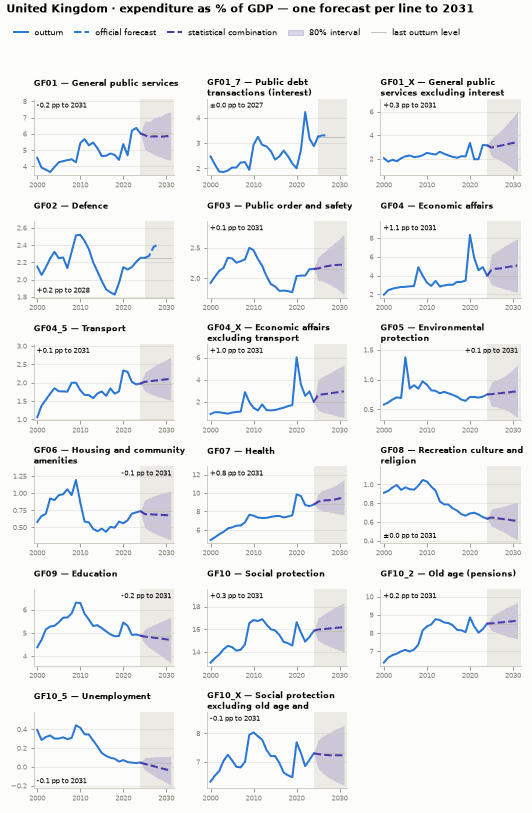

17 lines, one per COFOG function, from 2000: 2 carry an official projection, 15 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [4]:
panel("GBR", "expenditure")

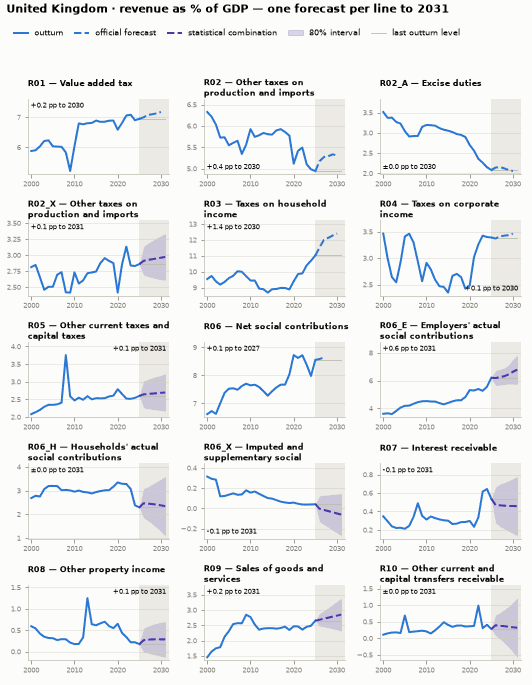

15 lines, one per ESA revenue type, from 2000: 6 carry an official projection, 9 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [5]:
panel("GBR", "revenue")

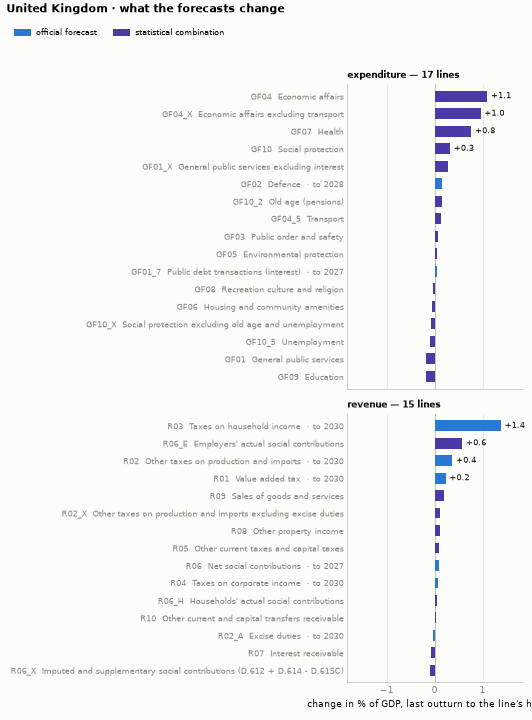

line     category                                     last outturn         forecast  change  source
GF01     General public services                       6.03 (2024)      5.85 (2031)   -0.17  statistical
GF01_7   Public debt transactions (interest)           3.25 (2025)      3.29 (2027)   +0.04  official
GF01_X   General public services excluding intere      3.15 (2024)      3.42 (2031)   +0.28  statistical
GF02     Defence                                       2.25 (2025)      2.41 (2028)   +0.16  official
GF03     Public order and safety                       2.15 (2024)      2.22 (2031)   +0.07  statistical
GF04     Economic affairs                              3.97 (2024)      5.07 (2031)   +1.10  statistical
GF04_5   Transport                                     1.98 (2024)      2.11 (2031)   +0.13  statistical
GF04_X   Economic affairs excluding transport          1.99 (2024)      2.95 (2031)   +0.96  statistical
GF05     Environmental protection                      0.75 (2024)

In [6]:
changes("GBR")

## 1.2 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

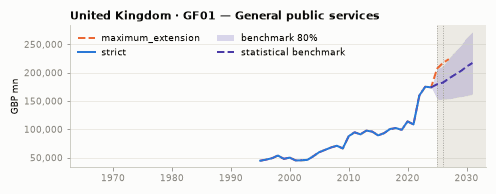

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO, grade D)
          ·  2026-2027: proxy forecast (EC_AMECO, grade D)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. §7.9: GF01
          total has no direct forecast source; strict ends at the last actual — maximum_extension
          carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method
          recorded; D-S4-002)
maximum:  projects to 2027 — §7.9: GF01 total has no direct forecast source; strict ends at the last
          actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage
          measured, residual_method recorded; D-S4-002)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 217,128 GBP mn (80%
          162,125 to 272,131), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not

In [7]:
chart("GBR", "GF01")

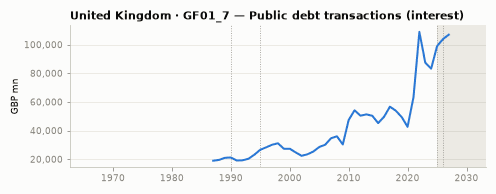

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-1994: backward stitch
          (ONS_PSF_INTEREST, grade B)  ·  1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025:
          forward stitch (EC_AMECO, grade B)  ·  2026-2027: official forecast (EC_AMECO, grade B)
outturn:  1987-2025
both:     projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [8]:
chart("GBR", "GF01_7")

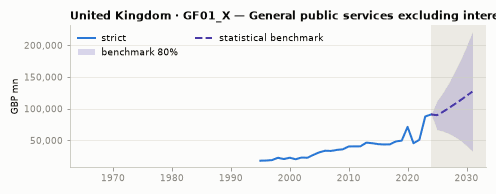

recipe:   1995-2024: derived by identity (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 127,050 GBP mn (80%
          32,798 to 221,302), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [9]:
chart("GBR", "GF01_X")

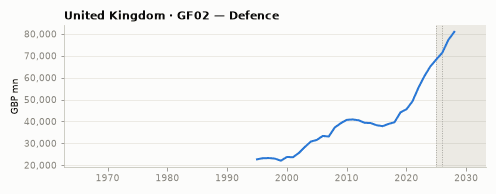

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (HMT_PESA, grade B)
          ·  2026-2028: official forecast (HMT_PESA, grade B)
outturn:  1995-2025
both:     projects to 2028 — source horizon: HMT_PESA ends 2028 (V10)


In [10]:
chart("GBR", "GF02")

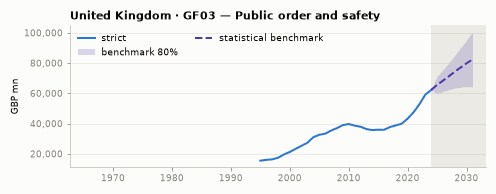

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 82,423 GBP mn (80%
          64,185 to 100,660), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [11]:
chart("GBR", "GF03")

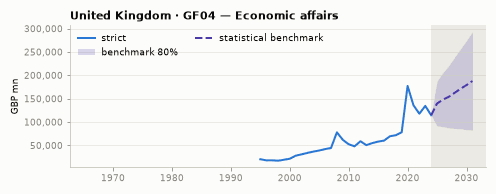

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 188,007 GBP mn (80%
          82,877 to 293,136), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [12]:
chart("GBR", "GF04")

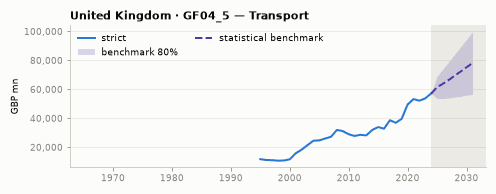

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          institution publishes a projection of transport spending on the COFOG 04.5 concept; strict and
          maximum end at the last actual (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 78,130 GBP mn (80%
          56,519 to 99,742), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [13]:
chart("GBR", "GF04_5")

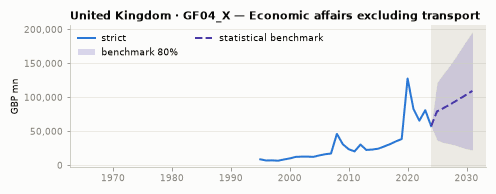

recipe:   1995-2024: derived by identity (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder GF04 - GF04_5 is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 109,459 GBP mn (80%
          22,466 to 196,452), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [14]:
chart("GBR", "GF04_X")

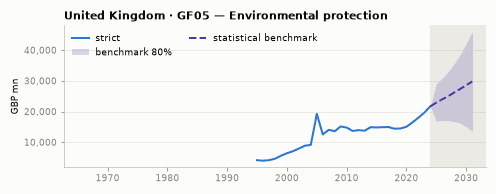

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 29,782 GBP mn (80%
          13,598 to 45,966), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [15]:
chart("GBR", "GF05")

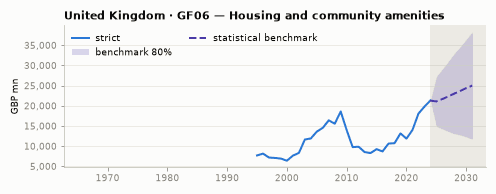

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 25,035 GBP mn (80%
          11,733 to 38,336), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [16]:
chart("GBR", "GF06")

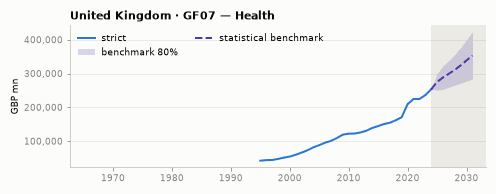

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. FRS July 2025 (hand-
          retrieved, D-S7-001) is thematic — pensions, balance sheet, climate — and carries no long-term
          health projection; the FRS edition with functional long-term projections (2024, or 2026 if
          published) is not in hand and obr.uk remains challenge-blocked (OQ-6); strict ends at the last
          actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 353,279 GBP mn (80%
          283,428 to 423,130), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [17]:
chart("GBR", "GF07")

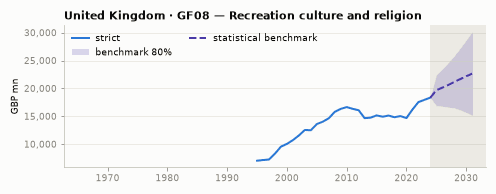

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 22,649 GBP mn (80%
          15,157 to 30,142), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [18]:
chart("GBR", "GF08")

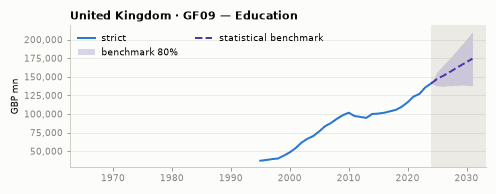

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. as GF07: no
          education long-term projection in the FRS July 2025 edition in hand (OQ-6); strict ends at the
          last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 174,285 GBP mn (80%
          138,116 to 210,453), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [19]:
chart("GBR", "GF09")

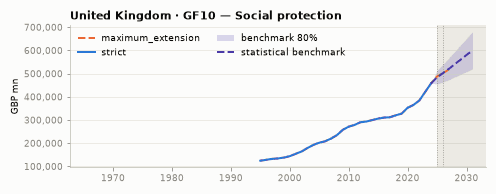

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO, grade C)
          ·  2026-2027: proxy forecast (EC_AMECO, grade C)
outturn:  1995-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict.
          maximum_extension carries the AMECO D.62 dominant-component proxy to 2027 (grade C, §7.8); the
          EFO welfare-spending series was measured as a longer C-band candidate but its table starts at
          FY 2024-25, leaving no year in common with the GG anchor to measure §9.2 coverage on —
          recorded, not applied (D-S7-003)
maximum:  projects to 2027 — maximum_extension carries the AMECO D.62 dominant-component proxy to 2027
          (grade C, §7.8); the EFO welfare-spending series was measured as a longer C-band candidate but
          its table starts at FY 2024-25, leaving no year in common with the GG anchor to measure §9.2
          coverage on — recorded, not applied (D-S7-003)
benchmar

In [20]:
chart("GBR", "GF10")

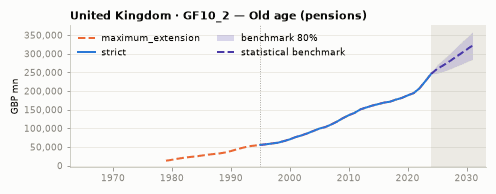

recipe:   1979-1994: backward stitch (OBR_HIST_PF, grade C)  ·  1995-2024: anchor outturn (ONS_ESA_T11,
          grade A)
outturn:  1979-2024
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. the only reachable
          old-age projection is EFO 4.9 State pension, whose table starts at FY 2024-25 — no year in
          common with the GG anchor, §9.2 coverage unmeasurable, recorded not applied (D-S13-002); the
          OBR historical database's pensioner-spending series ends 2022-23 and cannot bridge the gap; an
          FRS edition with long-term state-pension projections is the named ask (OQ-6 a)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 321,750 GBP mn (80%
          284,749 to 358,752), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [21]:
chart("GBR", "GF10_2")

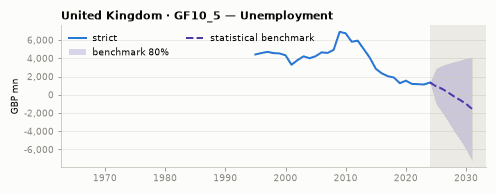

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          institution publishes a projection of unemployment benefits on the COFOG 10.5 concept (AMECO's
          UUTZ105 is the cyclical component of the deficit, not the line; the AR covers pensions,
          health, LTC, education only); strict and maximum end at the last actual (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — -1,547 GBP mn (80%
          -7,232 to 4,138), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [22]:
chart("GBR", "GF10_5")

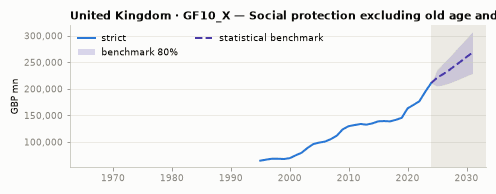

recipe:   1995-2024: derived by identity (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-002, the D10 pattern): the remainder GF10 - GF10_2 - GF10_5 is
          derived only, so the GF10 identity stays exact in every published year
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 268,216 GBP mn (80%
          229,091 to 307,341), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [23]:
chart("GBR", "GF10_X")

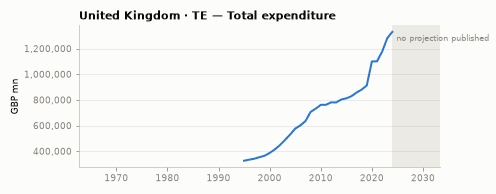

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path


In [24]:
chart("GBR", "TE")

## 1.3 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

## 1.4 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

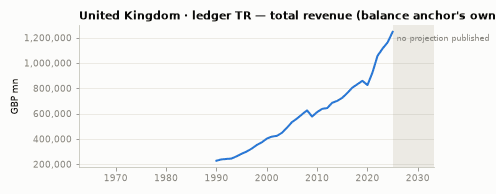

outturn:  1990-2025, source ONS_GG_RECEIPTS
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [25]:
ledger_chart("GBR", "TR")

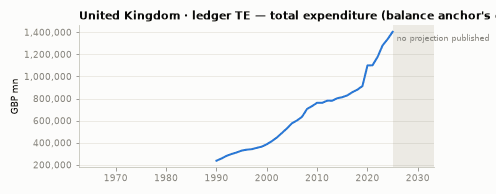

outturn:  1990-2025, source ONS_GG_RECEIPTS
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [26]:
ledger_chart("GBR", "TE")

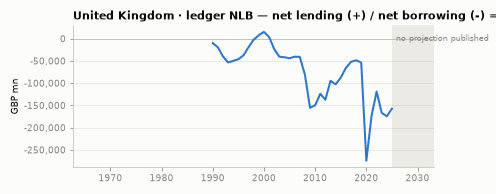

outturn:  1990-2025, source ONS_GG_RECEIPTS
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [27]:
ledger_chart("GBR", "NLB")

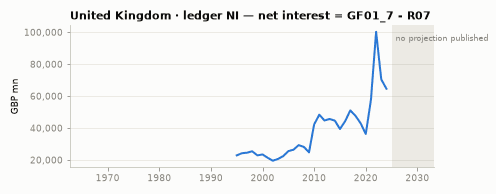

outturn:  1990-2025, source ONS_GG_RECEIPTS; no value for [1990, 1991, 1992, 1993, 1994, 2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [28]:
ledger_chart("GBR", "NI")

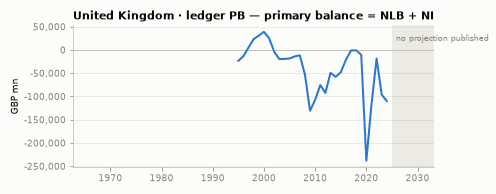

outturn:  1990-2025, source ONS_GG_RECEIPTS; no value for [1990, 1991, 1992, 1993, 1994, 2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [29]:
ledger_chart("GBR", "PB")

---

# 2. France (FRA)

## 2.1 Forecast panel — every category at a glance

Expenditure then revenue, as a share of GDP, each line carrying the one forecast this book would quote for it — the official projection where one is published, the statistical combination where none is. Then the same panel as a single ranked picture: the change each line is forecast to make between its last outturn and its horizon, largest first.

This is the summary; the per-series charts that follow are the evidence.


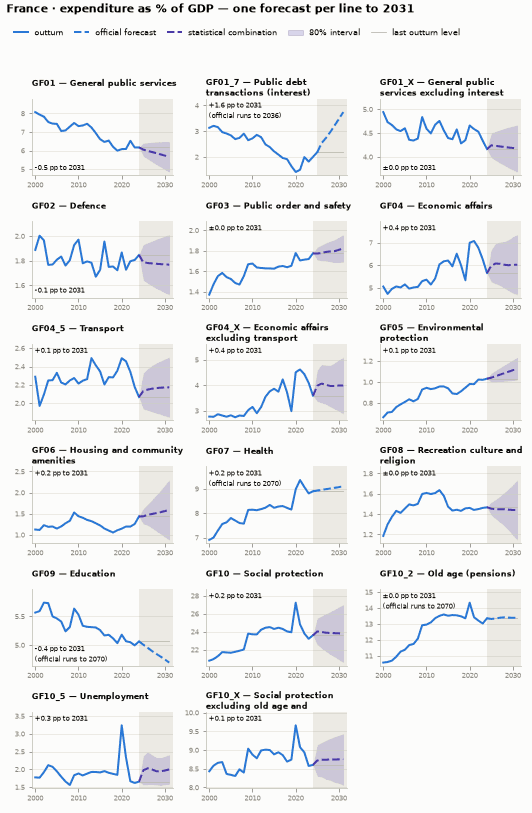

17 lines, one per COFOG function, from 2000: 4 carry an official projection, 13 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [30]:
panel("FRA", "expenditure")

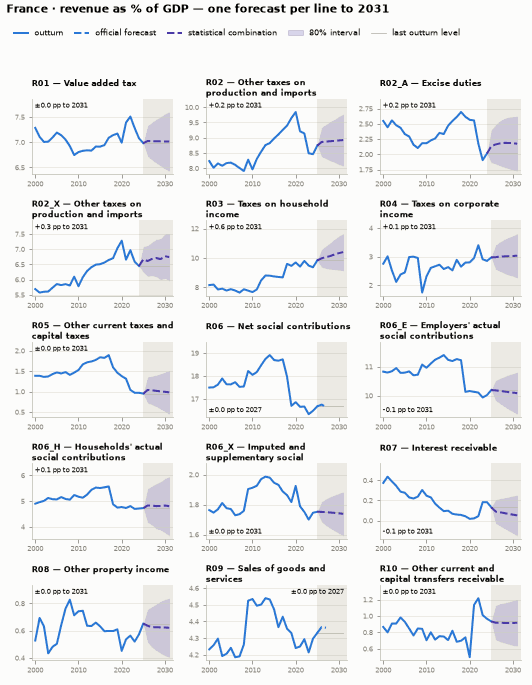

15 lines, one per ESA revenue type, from 2000: 2 carry an official projection, 13 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [31]:
panel("FRA", "revenue")

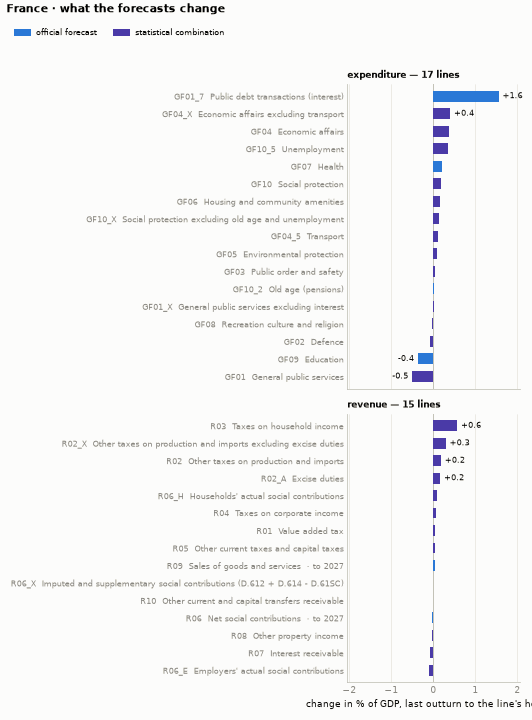

line     category                                     last outturn         forecast  change  source
GF01     General public services                       6.17 (2024)      5.67 (2031)   -0.50  statistical
GF01_7   Public debt transactions (interest)           2.19 (2025)      3.74 (2031)   +1.55  official (runs to 2036)
GF01_X   General public services excluding intere      4.16 (2024)      4.17 (2031)   +0.01  statistical
GF02     Defence                                       1.85 (2024)      1.77 (2031)   -0.08  statistical
GF03     Public order and safety                       1.78 (2024)      1.82 (2031)   +0.05  statistical
GF04     Economic affairs                              5.66 (2024)      6.03 (2031)   +0.37  statistical
GF04_5   Transport                                     2.07 (2024)      2.17 (2031)   +0.11  statistical
GF04_X   Economic affairs excluding transport          3.59 (2024)      3.99 (2031)   +0.40  statistical
GF05     Environmental protection               

In [32]:
changes("FRA")

## 2.2 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

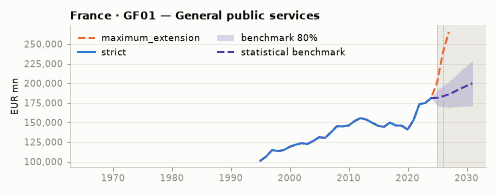

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO,
          grade D)  ·  2026-2027: proxy forecast (EC_AMECO, grade D)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. §7.9: GF01
          total has no direct forecast source; strict ends at the last actual — maximum_extension
          carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method
          recorded; D-S4-002)
maximum:  projects to 2027 — §7.9: GF01 total has no direct forecast source; strict ends at the last
          actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage
          measured, residual_method recorded; D-S4-002)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 199,957 EUR mn (80%
          170,966 to 228,948), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a bench

In [33]:
chart("FRA", "GF01")

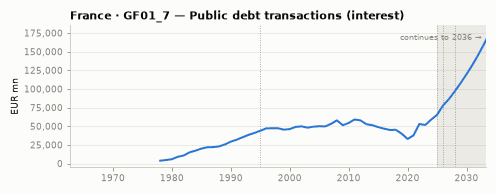

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade B)  ·  2026-2027:
          official forecast (EC_AMECO, grade B)  ·  2028-2036: official forecast (EC_DSM, grade B)
outturn:  1978-2025
both:     projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [34]:
chart("FRA", "GF01_7")

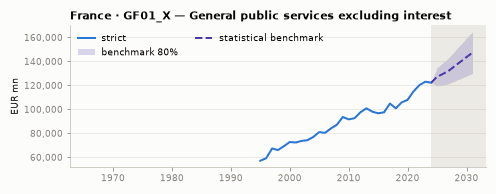

recipe:   1995-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 147,295 EUR mn (80%
          129,904 to 164,686), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [35]:
chart("FRA", "GF01_X")

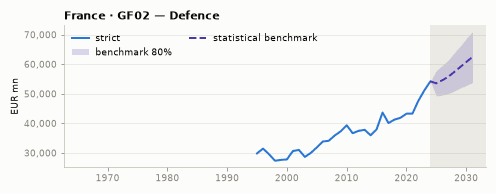

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPM_2030 (military programming law) is PDF-only; §11.4 manual ingestion requires an
          independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6;
          strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 62,378 EUR mn (80%
          53,787 to 70,969), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [36]:
chart("FRA", "GF02")

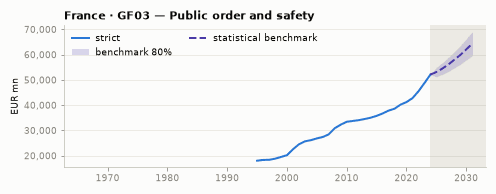

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 64,311 EUR mn (80%
          59,582 to 69,039), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [37]:
chart("FRA", "GF03")

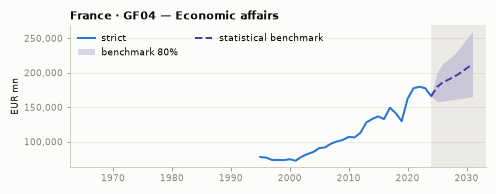

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 212,591 EUR mn (80%
          165,801 to 259,380), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [38]:
chart("FRA", "GF04")

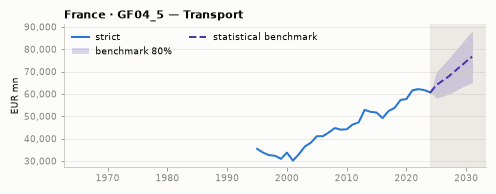

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          institution publishes a projection of transport spending on the COFOG 04.5 concept; strict and
          maximum end at the last actual (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 76,669 EUR mn (80%
          65,140 to 88,198), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [39]:
chart("FRA", "GF04_5")

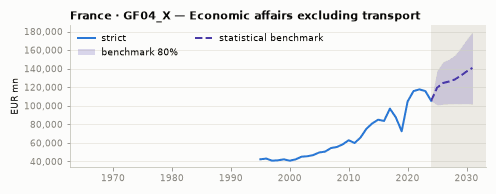

recipe:   1995-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder GF04 - GF04_5 is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 140,722 EUR mn (80%
          101,793 to 179,651), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [40]:
chart("FRA", "GF04_X")

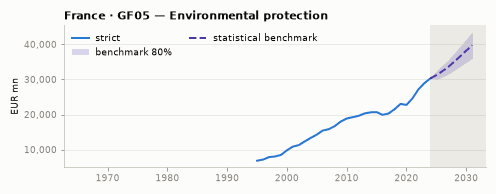

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 39,779 EUR mn (80%
          35,985 to 43,572), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [41]:
chart("FRA", "GF05")

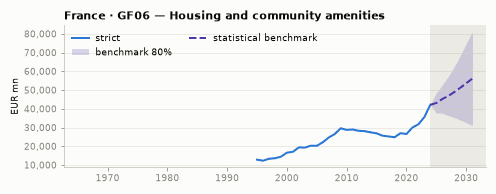

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 56,056 EUR mn (80%
          31,033 to 81,080), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [42]:
chart("FRA", "GF06")

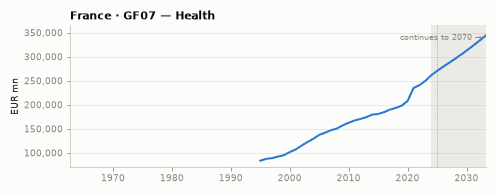

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
          (EC_AGEING_2024, grade B)
outturn:  1995-2024
both:     projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [43]:
chart("FRA", "GF07")

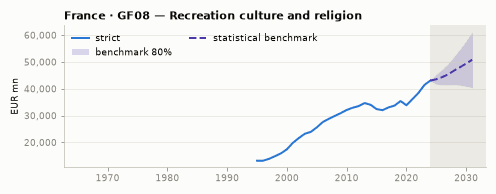

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 50,845 EUR mn (80%
          40,443 to 61,246), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [44]:
chart("FRA", "GF08")

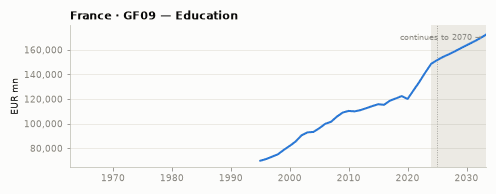

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
          (EC_AGEING_2024, grade B)
outturn:  1995-2024
both:     projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [45]:
chart("FRA", "GF09")

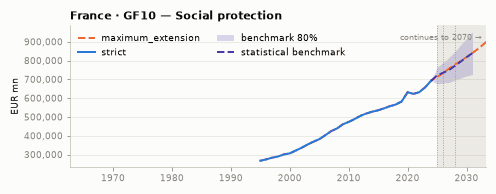

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO,
          grade C)  ·  2026-2027: proxy forecast (EC_AMECO, grade C)  ·  2028-2070: composite forecast
          (EC_AGEING_2024, grade C)
outturn:  1995-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AR
          pensions+LTC composite measured at 69% of GF10 (grade C: no official projection of
          family/housing/unemployment components) — no strict forecast; maximum_extension chains the
          AMECO D.62 proxy (to 2027) into the AR composite (to 2070) per D12, overlap divergence under
          the V16 threshold
maximum:  projects to 2070 — AR pensions+LTC composite measured at 69% of GF10 (grade C: no official
          projection of family/housing/unemployment components) — no strict forecast; maximum_extension
          chains the AMECO D.62 proxy (to 2027) into the AR composite (to 2070) per D12, overlap
          diverg

In [46]:
chart("FRA", "GF10")

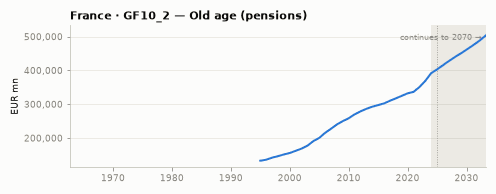

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
          (EC_AGEING_2024, grade B)
outturn:  1995-2024
both:     projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [47]:
chart("FRA", "GF10_2")

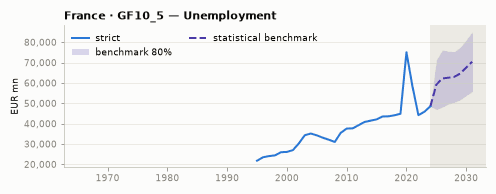

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          institution publishes a projection of unemployment benefits on the COFOG 10.5 concept (AMECO's
          UUTZ105 is the cyclical component of the deficit, not the line; the AR covers pensions,
          health, LTC, education only); strict and maximum end at the last actual (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 70,439 EUR mn (80%
          55,766 to 85,113), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [48]:
chart("FRA", "GF10_5")

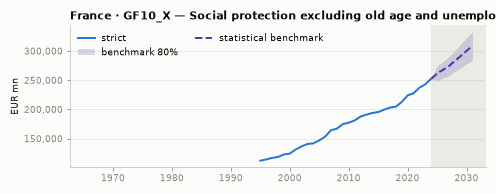

recipe:   1995-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-002, the D10 pattern): the remainder GF10 - GF10_2 - GF10_5 is
          derived only, so the GF10 identity stays exact in every published year
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 308,669 EUR mn (80%
          284,418 to 332,921), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [49]:
chart("FRA", "GF10_X")

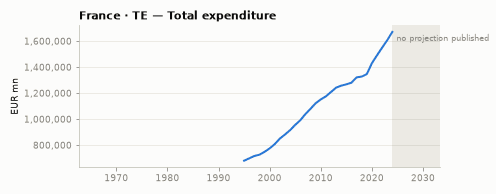

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path


In [50]:
chart("FRA", "TE")

## 2.3 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

## 2.4 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

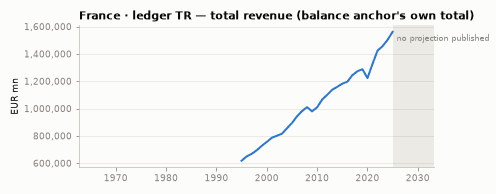

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [51]:
ledger_chart("FRA", "TR")

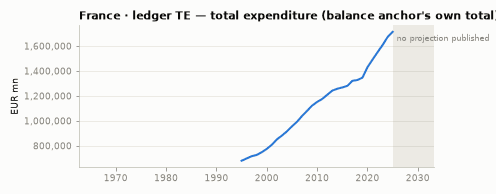

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [52]:
ledger_chart("FRA", "TE")

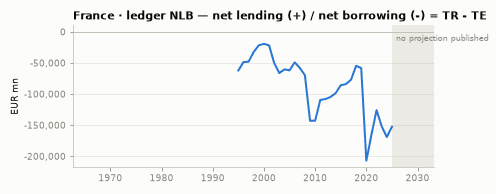

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [53]:
ledger_chart("FRA", "NLB")

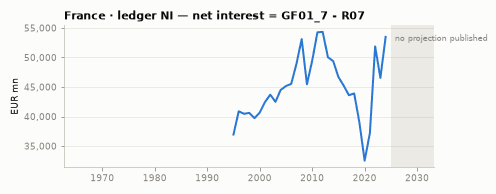

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [54]:
ledger_chart("FRA", "NI")

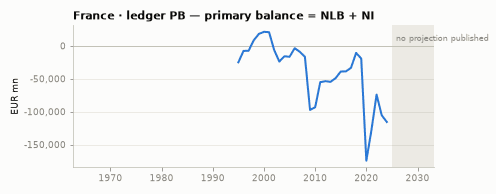

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [55]:
ledger_chart("FRA", "PB")

---

# 3. Germany (DEU)

## 3.1 Forecast panel — every category at a glance

Expenditure then revenue, as a share of GDP, each line carrying the one forecast this book would quote for it — the official projection where one is published, the statistical combination where none is. Then the same panel as a single ranked picture: the change each line is forecast to make between its last outturn and its horizon, largest first.

This is the summary; the per-series charts that follow are the evidence.


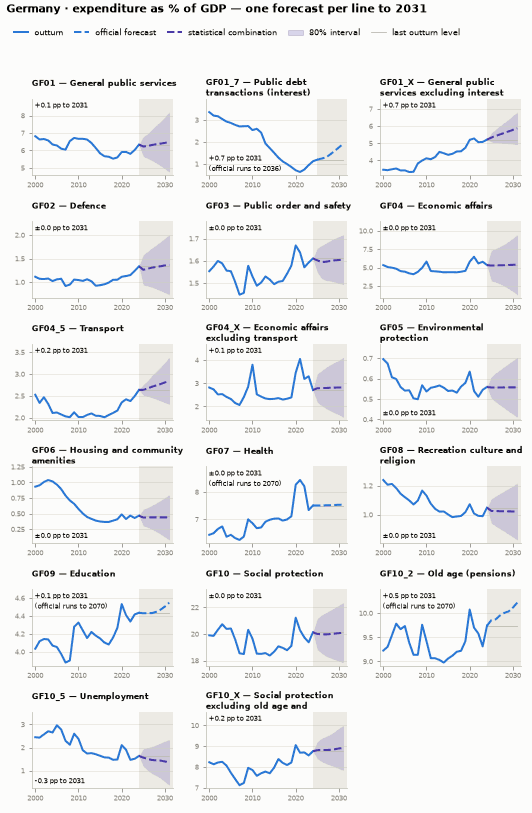

17 lines, one per COFOG function, from 2000: 4 carry an official projection, 13 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [56]:
panel("DEU", "expenditure")

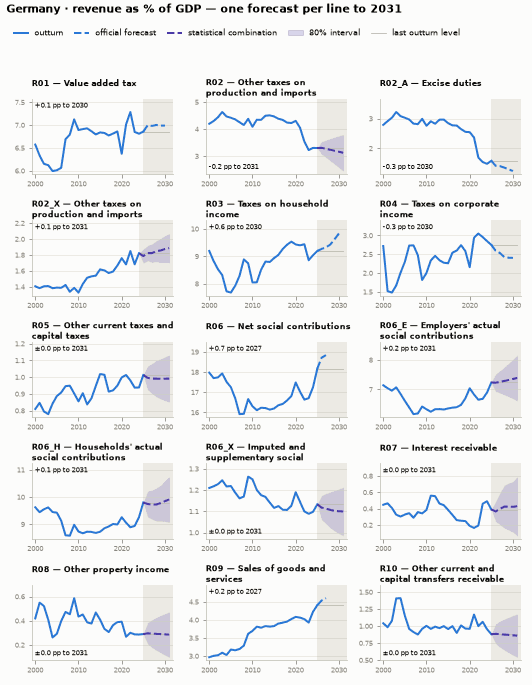

15 lines, one per ESA revenue type, from 2000: 6 carry an official projection, 9 take the statistical combination. Levels, seams and the recipe behind each line are in the per-series charts below.


In [57]:
panel("DEU", "revenue")

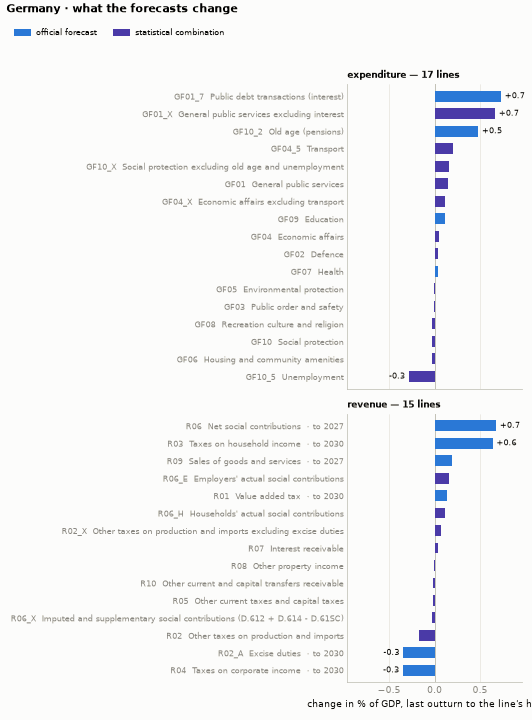

line     category                                     last outturn         forecast  change  source
GF01     General public services                       6.33 (2024)      6.48 (2031)   +0.15  statistical
GF01_7   Public debt transactions (interest)           1.19 (2025)      1.92 (2031)   +0.73  official (runs to 2036)
GF01_X   General public services excluding intere      5.21 (2024)      5.87 (2031)   +0.66  statistical
GF02     Defence                                       1.34 (2024)      1.37 (2031)   +0.03  statistical
GF03     Public order and safety                       1.61 (2024)      1.61 (2031)   -0.01  statistical
GF04     Economic affairs                              5.35 (2024)      5.39 (2031)   +0.05  statistical
GF04_5   Transport                                     2.64 (2024)      2.84 (2031)   +0.21  statistical
GF04_X   Economic affairs excluding transport          2.71 (2024)      2.83 (2031)   +0.12  statistical
GF05     Environmental protection               

In [58]:
changes("DEU")

## 3.2 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

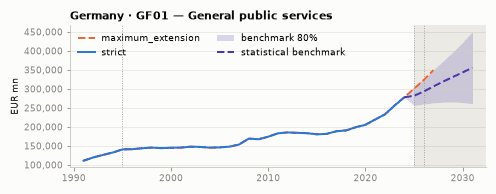

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade D)  ·  2026-2027:
          proxy forecast (EC_AMECO, grade D)
outturn:  1991-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. §7.9: GF01
          total has no direct forecast source; strict ends at the last actual — maximum_extension
          carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method
          recorded; D-S4-002)
maximum:  projects to 2027 — §7.9: GF01 total has no direct forecast source; strict ends at the last
          actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage
          measured, residual_method recorded; D-S4-002)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 355,788 EUR mn (80%
          261,443 to 450,134), on GDP anchored_outturn_chained_on_w

In [59]:
chart("DEU", "GF01")

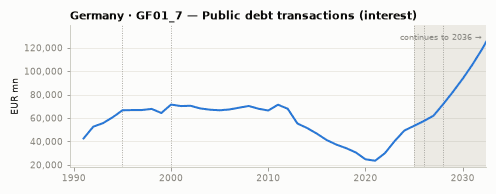

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-1999: anchor outturn on the D10
          fallback concept (EUROSTAT_GOV10A_EXP, grade B)  ·  2000-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade B)  ·  2026-2027:
          official forecast (EC_AMECO, grade B)  ·  2028-2036: official forecast (EC_DSM, grade B)
outturn:  1991-2025
both:     projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [60]:
chart("DEU", "GF01_7")

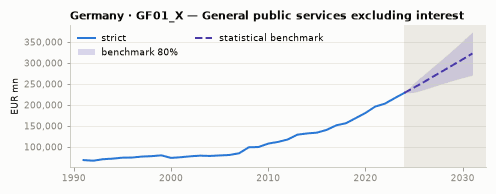

recipe:   1991-1999: derived by identity (EUROSTAT_GOV10A_EXP, grade B)  ·  2000-2024: derived by
          identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 322,489 EUR mn (80%
          270,893 to 374,085), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [61]:
chart("DEU", "GF01_X")

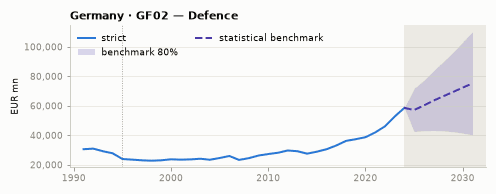

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          DEU_BMF_FINPLAN (Epl. 14 + Sondervermögen Bundeswehr) is PDF-only; §11.4 manual ingestion
          requires an independent second keying unavailable to a single-agent session (OQ-5 precedent) —
          OQ-6; strict ends at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 75,214 EUR mn (80%
          40,258 to 110,170), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [62]:
chart("DEU", "GF02")

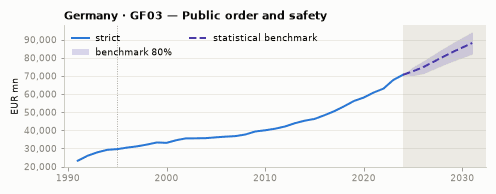

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 88,158 EUR mn (80%
          82,021 to 94,295), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [63]:
chart("DEU", "GF03")

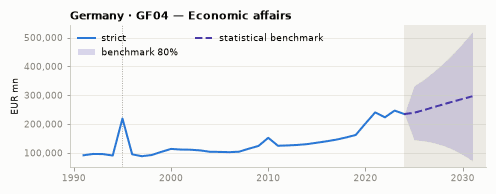

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 296,202 EUR mn (80%
          72,790 to 519,613), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [64]:
chart("DEU", "GF04")

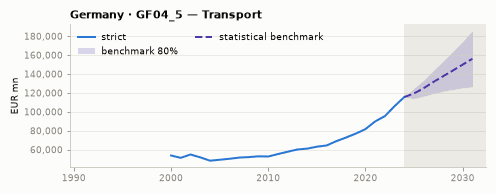

recipe:   2000-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  2000-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          institution publishes a projection of transport spending on the COFOG 04.5 concept; strict and
          maximum end at the last actual (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 156,118 EUR mn (80%
          126,589 to 185,647), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [65]:
chart("DEU", "GF04_5")

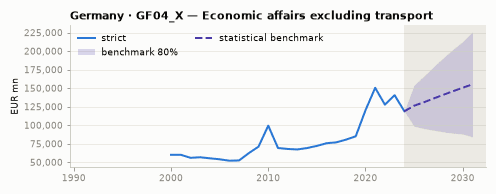

recipe:   2000-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  2000-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-005): the remainder GF04 - GF04_5 is derived only
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 155,157 EUR mn (80%
          84,297 to 226,016), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [66]:
chart("DEU", "GF04_X")

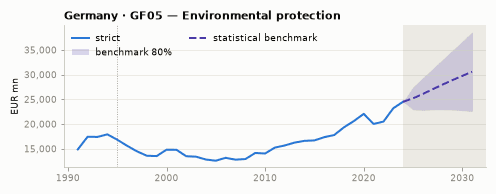

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 30,602 EUR mn (80%
          22,543 to 38,662), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [67]:
chart("DEU", "GF05")

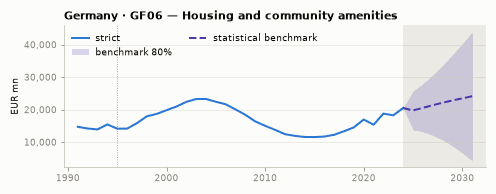

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 24,115 EUR mn (80% 4,291
          to 43,939), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn only; a
          benchmark, not a published forecast.


In [68]:
chart("DEU", "GF06")

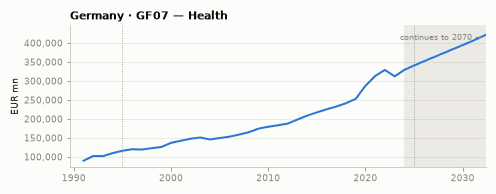

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast (EC_AGEING_2024, grade B)
outturn:  1991-2024
both:     projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [69]:
chart("DEU", "GF07")

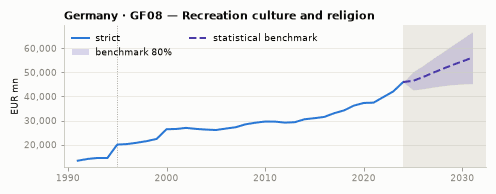

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 56,084 EUR mn (80%
          45,332 to 66,837), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [70]:
chart("DEU", "GF08")

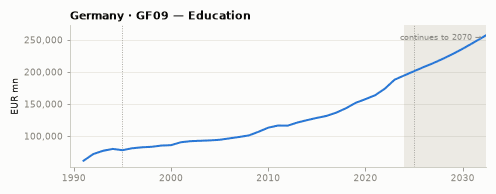

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast (EC_AGEING_2024, grade B)
outturn:  1991-2024
both:     projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [71]:
chart("DEU", "GF09")

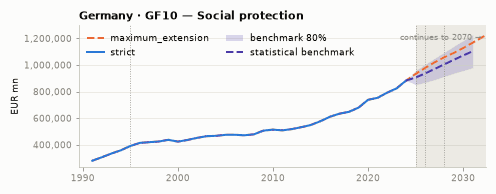

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade C)  ·  2026-2027:
          proxy forecast (EC_AMECO, grade C)  ·  2028-2070: composite forecast (EC_AGEING_2024, grade C)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AR
          pensions+LTC composite measured at 61% of GF10 (grade C); BMAS Rentenversicherungsbericht
          blocked (bmas.de egress, OQ-6) — no strict forecast; maximum_extension chains the AMECO D.62
          proxy (to 2027) into the AR composite (to 2070) per D12
maximum:  projects to 2070 — AR pensions+LTC composite measured at 61% of GF10 (grade C); BMAS
          Rentenversicherungsbericht blocked (bmas.de egress, OQ-6) — no strict forecast;
          maximum_extension chains the AMECO D.62 proxy (to 2027) into the AR composite (to 2070) per
          D12
benchmark: statistical 

In [72]:
chart("DEU", "GF10")

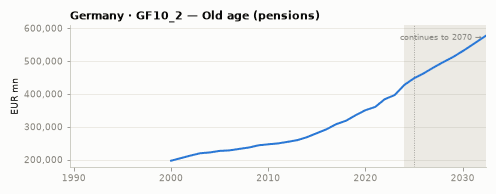

recipe:   2000-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
          (EC_AGEING_2024, grade B)
outturn:  2000-2024
both:     projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [73]:
chart("DEU", "GF10_2")

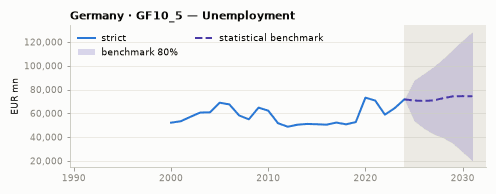

recipe:   2000-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  2000-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          institution publishes a projection of unemployment benefits on the COFOG 10.5 concept (AMECO's
          UUTZ105 is the cyclical component of the deficit, not the line; the AR covers pensions,
          health, LTC, education only); strict and maximum end at the last actual (D-S13-005)
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 74,317 EUR mn (80%
          20,106 to 128,527), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [74]:
chart("DEU", "GF10_5")

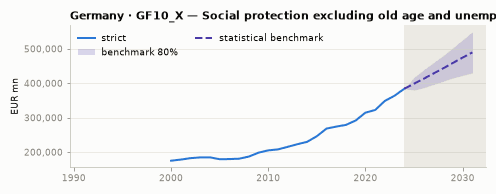

recipe:   2000-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  2000-2024
both:     NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D-S13-002, the D10 pattern): the remainder GF10 - GF10_2 - GF10_5 is
          derived only, so the GF10 identity stays exact in every published year
benchmark: statistical combination of auto.arima, ets, prophet and uc to 2031 — 489,667 EUR mn (80%
          430,072 to 549,261), on GDP anchored_outturn_chained_on_weo_ngdp from 2024. Fitted on outturn
          only; a benchmark, not a published forecast.


In [75]:
chart("DEU", "GF10_X")

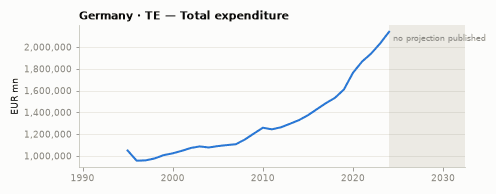

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
both:     NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path


In [76]:
chart("DEU", "TE")

## 3.3 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

## 3.4 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

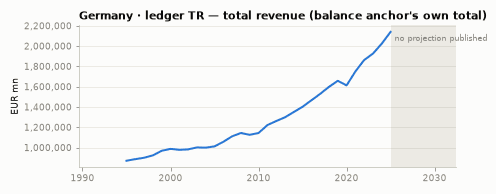

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [77]:
ledger_chart("DEU", "TR")

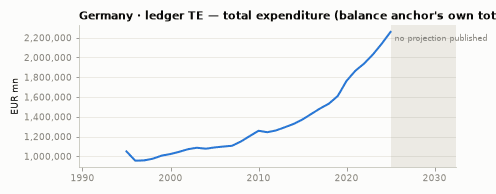

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [78]:
ledger_chart("DEU", "TE")

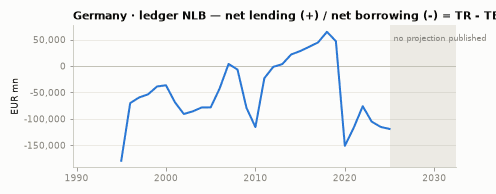

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [79]:
ledger_chart("DEU", "NLB")

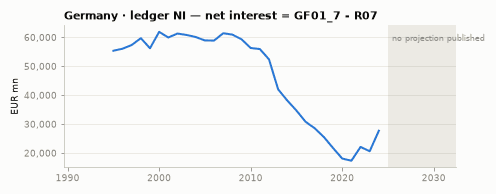

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [80]:
ledger_chart("DEU", "NI")

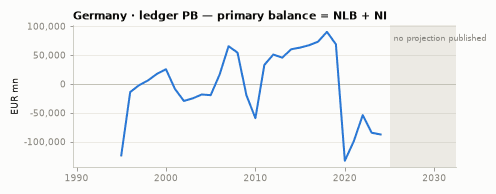

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [81]:
ledger_chart("DEU", "PB")

---

# 4. Reconciliation to the IMF WEO

Do our totals agree with the IMF's? Each chart puts our number and the WEO's on
the same axes over every overlap year, with the gap as a percentage of our total
expenditure underneath.

What to look for: a gap that is **small and flat** is a definitional
difference — a stable perimeter wedge — and is fine. A gap that **drifts or
jumps** is a vintage difference or something that needs explaining, and the
`gap_classification` column in the caption says which the pipeline decided it
was (`perimeter`, `revision`, or `unexplained`).

These are history-only, because our ledger is history-only: the WEO's forecast
has nothing on our side to sit beside. §4.4 handles the forecast side, where the
comparison is a decomposition rather than a level. The years after the last
outturn are therefore shaded with nothing in them, on the same country axis as
sections 1–3.

## 4.1 United Kingdom

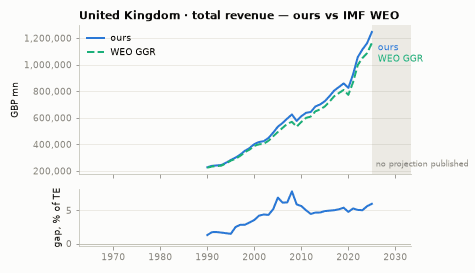

WEO vintage 2026-04; overlap 1990-2025; gap mean +4.355% of TE, sigma 1.662, range +1.281 to +7.849; classified: perimeter, unexplained


In [82]:
weo_chart("GBR", "revenue")

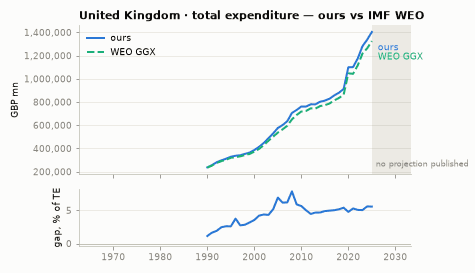

WEO vintage 2026-04; overlap 1990-2025; gap mean +4.458% of TE, sigma 1.500, range +1.130 to +7.849; classified: perimeter, unexplained


In [83]:
weo_chart("GBR", "expenditure")

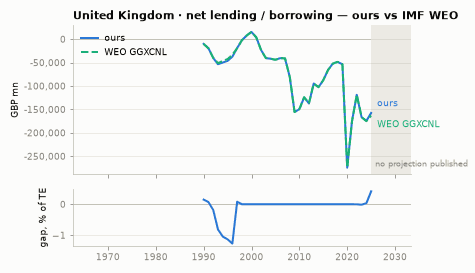

WEO vintage 2026-04; overlap 1990-2025; gap mean -0.103% of TE, sigma 0.358, range -1.267 to +0.417; classified: perimeter, unexplained


In [84]:
weo_chart("GBR", "nlb")

## 4.2 France

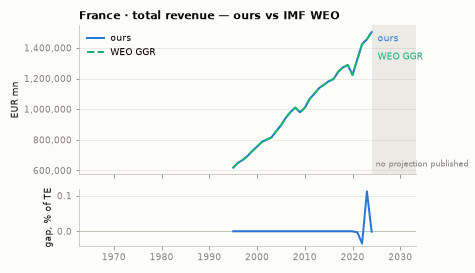

WEO vintage 2026-04; overlap 1995-2024; gap mean +0.002% of TE, sigma 0.022, range -0.034 to +0.112; classified: revision


In [85]:
weo_chart("FRA", "revenue")

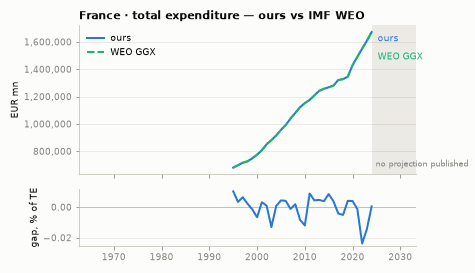

WEO vintage 2026-04; overlap 1995-2024; gap mean -0.000% of TE, sigma 0.008, range -0.024 to +0.010; classified: revision


In [86]:
weo_chart("FRA", "expenditure")

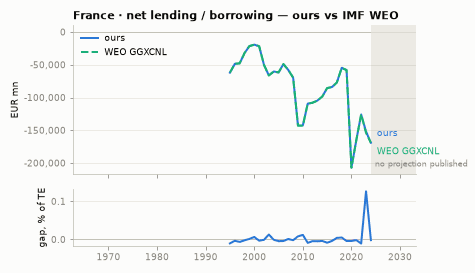

WEO vintage 2026-04; overlap 1995-2024; gap mean +0.003% of TE, sigma 0.024, range -0.011 to +0.126; classified: revision


In [87]:
weo_chart("FRA", "nlb")

## 4.3 Germany

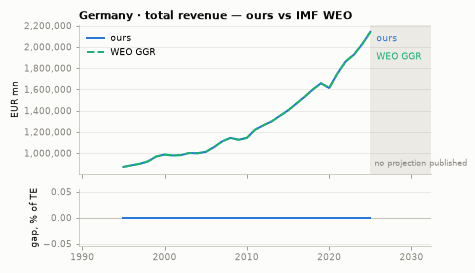

WEO vintage 2026-04; overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [88]:
weo_chart("DEU", "revenue")

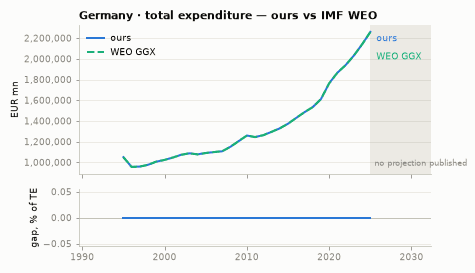

WEO vintage 2026-04; overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [89]:
weo_chart("DEU", "expenditure")

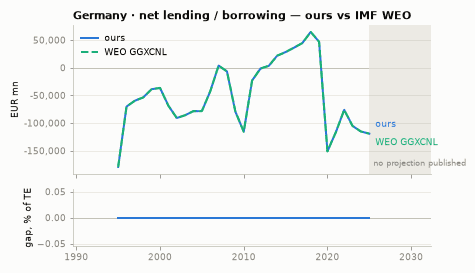

WEO vintage 2026-04; overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [90]:
weo_chart("DEU", "nlb")

## 4.4 The forecast side — and why there is no forward "our NLB"

The obvious question after §4.1–4.3: the WEO publishes a projected balance, so
why do the charts above stop at the last outturn instead of carrying our line
forward beside it?

Because **a level needs every component and a change does not.**

Our NLB is `TR − TE`, and TR and TE are the balance anchor's own published
totals. Those anchors publish outturns; nobody publishes a forward TR and TE on
our perimeter that this project ingests. The only way to state "our NLB in 2028"
would be to sum our forecast lines — and most lines have no forecast at all (44
of 132 series, §"Before the charts"). For the UK in 2028 that would mean adding
up defence and interest and four tax lines and calling the total "expenditure",
which would not be wrong by a little. So the ledger stops, and the honest answer
to "what is our NLB in 2028" is that we do not have one.

A *change* survives the same gaps, because the missing part can be named rather
than assumed. Each line we do forecast contributes its own
Δ(line/GDP) to the change in the balance; every line we do not forecast
contributes nothing to that covered total and is booked explicitly as
`resid_coverage`. Nothing is set to zero by accident — the hole is a number in
the table. That is what makes `explained_share` computable when a forward level
is not, and it is "decompose, never force" doing exactly the job it is for.

So the forward comparison the levels charts cannot make is made below in the
one form the data honestly supports.

One qualification, added since: the argument above is about *official*
forecasts, and it still holds for them. What has changed is the coverage
gap it turns on — the statistical benchmark now reaches every line, so a
balance can be summed without assuming anything about the lines nobody
forecasts. §4.5 does that, and is careful to call the result a benchmark.

### The forward balance: what the covered forecasts account for

Two paths from the WEO's own base year, both in % of GDP:

* <span style="color:#1baf7a">**the IMF WEO's projected balance**</span> — the
  thing being explained;
* <span style="color:#2a78d6">**the covered-forecast path**</span> — the base
  year balance moved *only* by the lines we hold an official forecast for
  (<span style="color:#eb6834">dashed orange</span> for
  `maximum_extension`).

The vertical gap between them is the residual: coverage holes, disagreement
between our lines and the WEO, and the GDP denominator effect. It closes to
zero by construction only when the covered forecasts account for the whole
move.

**The covered-forecast path is not a forecast of our balance.** It is the base
year plus the part of the WEO's move our lines can account for. Read the gap,
not the level.

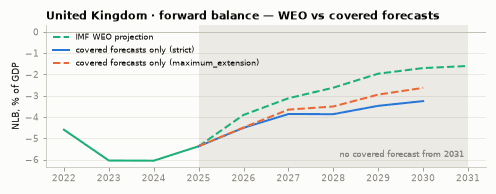

WEO vintage 2026-04; base 2025 at -5.38% of GDP.
  2031: WEO -1.60% of GDP; covered strict forecasts account for +0.00pp of the +3.77pp move, leaving +3.77pp in residuals.
  2030: WEO -1.70% of GDP; covered strict forecasts account for +2.12pp of the +3.68pp move, leaving +1.55pp in residuals.  (2031 has no covered forecast at all — every line's source horizon has run out by then.)


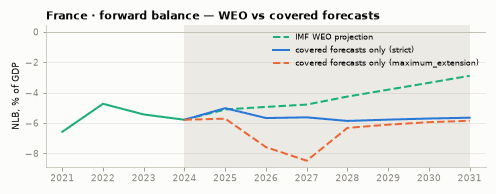

WEO vintage 2026-04; base 2024 at -5.79% of GDP.
  2031: WEO -2.89% of GDP; covered strict forecasts account for +0.13pp of the +2.89pp move, leaving +2.76pp in residuals.


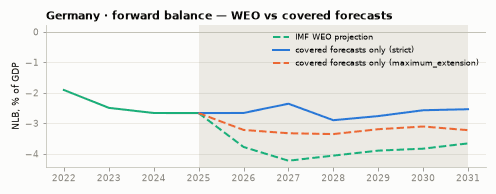

WEO vintage 2026-04; base 2025 at -2.67% of GDP.
  2031: WEO -3.66% of GDP; covered strict forecasts account for +0.13pp of the -0.99pp move, leaving -1.12pp in residuals.


In [91]:
def weo_forward(iso3, vintage=None):
    vintage = vintage or LATEST
    lv = LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year")
    base_year = int(lv.query("is_base_year").year.max())
    at_base = lv.query("year == @base_year").iloc[0]
    base = 100 * at_base.nlb_weo_mn / at_base.gdp_weo_mn

    # A short run-in only: the fork is the subject, and a decade of history
    # would drag 2020 onto the axis and squash the forward paths flat.
    hist = lv[lv.year.between(base_year - 3, base_year)].copy()
    hist["ratio"] = 100 * hist.nlb_weo_mn / hist.gdp_weo_mn
    fc = RECON.query("block == 'forecast' and iso3 == @iso3 and "
                     "weo_vintage == @vintage")
    move = fc.pivot_table(index=["variant", "year"], columns="component",
                          values="contribution_pp", aggfunc="sum")

    fig, ax = plt.subplots()
    ax.axvspan(base_year, XMAX, color=SHADE, zorder=0, lw=0)
    ax.plot(hist.year, hist.ratio, color=AQUA, lw=2)

    weo = move.loc["strict"].weo_change + base
    ax.plot([base_year, *weo.index], [base, *weo], color=AQUA, ls="--",
            label="IMF WEO projection")
    for variant, colour, style in (("strict", BLUE, "-"),
                                   ("maximum_extension", ORANGE, "--")):
        covered = move.loc[variant].covered_total.fillna(0) + base
        # A horizon with no covered line at all has no covered path — it is
        # undefined, not flat at the base year. Break the line rather than
        # draw a cliff back to base that reads as a projected deterioration.
        has_lines = set(fc.query("variant == @variant and "
                                 "component == 'covered_line'").year)
        covered = covered.where(covered.index.isin(has_lines))
        ax.plot([base_year, *covered.index], [base, *covered], color=colour,
                ls=style, label=f"covered forecasts only ({variant})")
        if covered.isna().any():
            first_gap = int(covered[covered.isna()].index.min())
            ax.annotate(f"no covered forecast from {first_gap}",
                        (first_gap, 0.06), xycoords=("data", "axes fraction"),
                        xytext=(-4, 0), textcoords="offset points",
                        color=MUTED, fontsize=7.5, va="bottom", ha="right")

    ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.set_xlim(base_year - 3.4, XMAX + 0.4)
    ax.set_title(f"{NAME[iso3]} · forward balance — WEO vs covered forecasts")
    ax.set_ylabel("NLB, % of GDP")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(1))
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    show(fig)

    strict = move.loc["strict"]
    covered = strict.covered_total.fillna(0)
    print(f"WEO vintage {vintage}; base {base_year} at {base:.2f}% of GDP.")

    def line(year):
        change, part = strict.weo_change[year], covered[year]
        return (f"  {year}: WEO {base + change:+.2f}% of GDP; covered strict "
                f"forecasts account for {part:+.2f}pp of the {change:+.2f}pp "
                f"move, leaving {change - part:+.2f}pp in residuals.")

    last = int(covered.index.max())
    print(line(last))
    covering = covered[covered != 0]
    if not covering.empty and int(covering.index.max()) != last:
        best = int(covering.index.max())
        print(line(best) + f"  ({last} has no covered forecast at all — every "
              "line's source horizon has run out by then.)")


for iso3 in ("GBR", "FRA", "DEU"):
    weo_forward(iso3)

### The same thing as a share

`explained_share` is that gap expressed as a ratio: covered contributions over
the WEO's change. 1.0 means fully accounted for, 0.0 means the projected move
sits entirely in residuals nobody publishes a forecast for.

A low share is a fact about the availability of official forecasts, not an
error in the data. Negative values mean the covered lines move *against* the
WEO's projected direction.

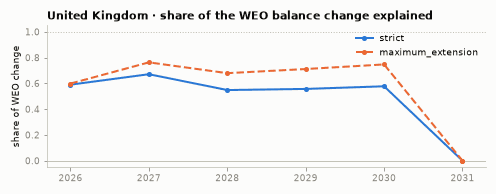

WEO vintage 2026-04; 1.0 = the covered official forecasts fully account for the projected move


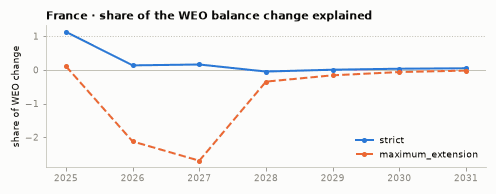

WEO vintage 2026-04; 1.0 = the covered official forecasts fully account for the projected move


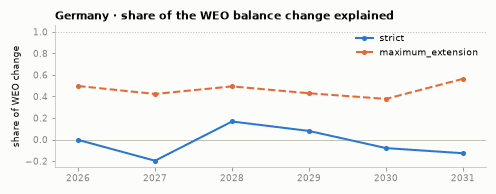

WEO vintage 2026-04; 1.0 = the covered official forecasts fully account for the projected move


In [92]:
def explained_share(iso3, vintage=None):
    vintage = vintage or LATEST
    d = RECON.query("block == 'forecast' and component == 'explained_share' "
                    "and iso3 == @iso3 and weo_vintage == @vintage")
    fig, ax = plt.subplots()
    for variant, colour, style in (("strict", BLUE, "-"),
                                   ("maximum_extension", ORANGE, "--")):
        s = d.query("variant == @variant").sort_values("year")
        ax.plot(s.year, s.contribution_pp, color=colour, ls=style,
                marker="o", markersize=4, label=variant)
    ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.axhline(1, color=AXIS, lw=1, ls=":", zorder=0)
    ax.set_title(f"{NAME[iso3]} · share of the WEO balance change explained")
    ax.set_ylabel("share of WEO change")
    ax.grid(axis="y")
    ax.set_xlim(d.year.min() - 0.3, XMAX + 0.3)
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(1))
    ax.grid(axis="y")
    ax.legend(loc="best")
    fig.tight_layout()
    show(fig)
    print(f"WEO vintage {vintage}; 1.0 = the covered official forecasts "
          "fully account for the projected move")


for iso3 in ("GBR", "FRA", "DEU"):
    explained_share(iso3)

## 4.5 The benchmark balance — the line forecasts read back as a deficit

§4.4 stops at "we do not have one", and for an *official* forward balance that
is still the answer. But the reason it gave was coverage — most lines had no
forecast, so a sum would have been mostly assumption — and that reason has
gone: every granular line now carries a statistical path to 2031, so the sum
is complete and the coverage residual is **zero by construction**.

So this section states the thing §4.4 could not: a **benchmark** balance. It is
the line forecasts added back up, on exactly the footing of the lines it is
built from. It is not our forecast of the deficit, nothing in it enters the
canonical layer or the trees, and where an official projection of the balance
exists it is the number and this is not.

`ggfiscal benchmark-balance` builds it into
[`../deliverables/benchmark_balance.csv`](../deliverables/benchmark_balance.csv);
this notebook only reads and plots. Four choices decide what it says, and each
one is visible in the file:

* **The base year is the last year every line has an outturn** — the
  expenditure tree ends a year before the revenue tree, so that is the
  expenditure tree's last actual, not the ledger's last year. The path starts
  from the balance ledger's own published NLB/GDP at that year, a real
  published balance rather than a sum of lines.
* **Expenditure is `GF01_7 + GF01_X + GF02…GF09 + GF10_2 + GF10_5 + GF10_X`,
  never `GF01…GF10`.** The two are the same identity in history. In forecast
  they are not: the Level I set hides the interest line inside `GF01`, whose
  own univariate fit knows nothing about the official interest projection. For
  France that choice is worth over two points of GDP by 2031, and it is the
  single largest judgement in this section. The same rule splits `GF10`
  (D-S13-007): for France and Germany the old-age pension line `GF10_2` is on
  the Ageing Report's official path, which `GF10` itself carries only in
  `maximum_extension`. A parent is split here exactly when one of its Level II
  lines has an official strict path to 2031 and the parent has not; `GF04` and
  the revenue splits stay as their parents.
* **An official projection is used only where it covers the whole horizon.**
  This is deliberately *not* the §*x*.1 panel's rule, which prefers an official
  projection at any horizon. A total needs every line in every year, and
  splicing a benchmark anchored at the last outturn onto an official path that
  has already moved away from it would invent a number that appears in no file.
  Seven UK lines, five German and two French therefore take their statistical
  path here while the panel above shows them official; the file names them in
  `source`.
* **The cone is the lines' own standard errors, propagated** under one average
  correlation within a side and one across the two, both estimated from the
  outturn history of the same lines. Independence would understate it — these
  lines move with the cycle together; a positive cross-side correlation is what
  lets a revenue miss and an expenditure miss cancel, and it is estimated
  rather than assumed. Lines on an official path contribute **no** variance,
  because a published projection is not a distribution, so where a country has
  official legs the cone is an understatement and the count is on every row.

The cone is wide. That is the honest answer and not a defect of the
construction: beside it each chart carries **±1 standard deviation of how far
that country's balance has actually moved** over the same number of years,
across the whole outturn record, and the model's band is the same order — for
the UK, a little wider. A balance six years out is genuinely this uncertain;
2009 and 2020 are both inside the record the yardstick is measured on.

One free mark. Because the revenue tree runs a year past the expenditure tree,
the first forecast year already has a published balance beside it — the only
outturn this construction can so far be scored against. The captions give the
miss.


In [93]:
# ------------------------------------------------------- the benchmark balance
#
# §4.4 says a forward "our NLB" cannot be stated, because a level needs every
# component and most lines had no forecast. The first half of that is still
# true and the second half is not: every granular line now carries a
# statistical path to 2031, so the sum is complete and the coverage residual
# is zero by construction. What comes out is a BENCHMARK balance — the line
# forecasts read back as a deficit — and it is on exactly the footing of the
# lines it is built from. It is not our forecast of the deficit, it is not in
# the canonical layer, and it does not go near the flat trees.
#
# `ggfiscal benchmark-balance` builds it; this notebook only reads and plots.
# The construction is in deliverables/benchmark_balance.csv and its module
# docstring; the three choices that matter are stated in the markdown above.

from matplotlib.patheffects import withStroke

BALANCE = load("benchmark_balance")
BAL = BALANCE.query("kind == 'balance'")
BAL_LINES = BALANCE.query("kind == 'line'")
COUNTRIES = ["GBR", "FRA", "DEU"]
BAL_FROM = 2000


def _ledger_nlb(iso3):
    """The published balance, as a share of GDP, over the outturn years."""
    g = (LEDGER.query("iso3 == @iso3 and variant == 'strict'")
         .dropna(subset=["nlb_lcu_mn", "gdp_lcu_mn"]).sort_values("year"))
    return (100 * g.nlb_lcu_mn / g.gdp_lcu_mn).set_axis(g.year.astype(int))


def balance_path():
    """One panel per country, on one axis: the published balance, then the
    benchmark forward with its 80% and 95% cone."""
    head = 0.78
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 3.5 + head), sharey=True)
    lo = min(BAL.lo95.min(), min(_ledger_nlb(i).loc[BAL_FROM:].min()
                                 for i in COUNTRIES)) - 0.8
    hi = max(BAL.hi95.max(), 0.8)

    for ax, iso3 in zip(axes, COUNTRIES):
        b = BAL.query("iso3 == @iso3").sort_values("year")
        base = int(b.base_year.iloc[0])
        hist = _ledger_nlb(iso3).loc[BAL_FROM:]
        anchor = float(b.anchor_pct_gdp.iloc[0])
        years = [base, *b.year]

        ax.set_xlim(BAL_FROM - 0.6, XMAX + 1.4)
        ax.set_ylim(lo, hi)
        ax.axvspan(base, XMAX + 0.6, color=SHADE, zorder=0, lw=0)
        ax.axhline(0, color=AXIS, lw=1, zorder=1)
        for low, high, alpha, label in (("lo95", "hi95", 0.16, "95%"),
                                        ("lo80", "hi80", 0.32, "80%")):
            ax.fill_between(years, [anchor, *b[low]], [anchor, *b[high]],
                            color=VIOLET, alpha=alpha, lw=0, zorder=1,
                            label=f"{label} interval")
        ax.plot(hist.index, hist.values, color=BLUE, label="published balance",
                zorder=3)
        # the central line sits inside its own band, so it carries a thin
        # surface stroke — without it a violet dash on violet shading is a
        # smudge rather than a path
        ax.plot(years, [anchor, *b.pct_gdp], color=VIOLET, ls="--", zorder=4,
                label="benchmark",
                path_effects=[withStroke(linewidth=3.6,
                                         foreground=SURFACE)])

        # the calibration mark: how far this balance has actually moved over
        # the same number of years, across the whole outturn record. Not an
        # interval and not used to build one — a yardstick for the cone.
        end = b.iloc[-1]
        sd = float(end.history_sd_pp)
        ax.errorbar([XMAX + 0.35], [float(end.pct_gdp)], yerr=[sd], fmt="none",
                    ecolor=MUTED, elinewidth=1, capsize=2.5, zorder=5,
                    label="±1 sd of history")

        ax.set_title(f"{NAME[iso3]}", fontsize=9.5)
        ax.grid(axis="y")
        ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
        ax.tick_params(labelsize=7.5)
        ax.annotate(f"{float(end.pct_gdp):+.1f} in {int(end.year)}",
                    (0.02, 0.03), xycoords="axes fraction", fontsize=7.5,
                    color=INK)
    axes[0].set_ylabel("balance, % of GDP")
    handles, labels = axes[0].get_legend_handles_labels()
    order = [labels.index(k) for k in ("published balance", "benchmark",
                                       "80% interval", "95% interval",
                                       "±1 sd of history")]
    fig.legend([handles[i] for i in order], [labels[i] for i in order],
               loc="upper left",
               bbox_to_anchor=(0.012, 1 - 0.30 / (3.5 + head)), ncol=5,
               fontsize=8, handlelength=1.8, columnspacing=1.3)
    fig.suptitle("The benchmark balance — the line forecasts read back as a "
                 f"deficit, to {XMAX}", fontsize=10.5, fontweight="bold",
                 x=0.012, ha="left", y=1 - 0.055 / (3.5 + head))
    fig.tight_layout(rect=(0, 0, 1, 1 - head / (3.5 + head)))
    show(fig)

    for iso3 in COUNTRIES:
        b = BAL.query("iso3 == @iso3").sort_values("year")
        end, base = b.iloc[-1], int(b.base_year.iloc[0])
        hist = _ledger_nlb(iso3)
        # the one year the construction can be marked against an outturn: the
        # revenue tree runs a year past the expenditure tree, so the first
        # forecast year already has a published balance to sit beside
        checks = [(y, float(b.query("year == @y").pct_gdp.iloc[0]), float(v))
                  for y, v in hist.items() if y in set(b.year)]
        print(f"{NAME[iso3]}: ledger {float(b.anchor_pct_gdp.iloc[0]):+.2f}% of "
              f"GDP in {base} → benchmark {float(end.pct_gdp):+.2f}% in "
              f"{int(end.year)} "
              f"[80% {float(end.lo80):+.2f} to {float(end.hi80):+.2f}, "
              f"95% {float(end.lo95):+.2f} to {float(end.hi95):+.2f}]")
        print(f"    interval from {int(end.n_statistical)} statistical lines "
              f"(rho_within {float(end.rho_within):+.2f}, rho_between "
              f"{float(end.rho_between):+.2f}, {int(end.n_corr_obs)} obs)"
              + (f"; {int(end.n_official)} official line(s) add none"
                 if int(end.n_official) else "")
              + f". Over {int(end.horizon)} years this balance has moved with "
                f"a standard deviation of {float(end.history_sd_pp):.2f} pp "
                f"({int(end.n_history_obs)} windows), against the cone's "
                f"{float(end.se):.2f}.")
        for year, said, was in checks:
            print(f"    {year} is already published: benchmark {said:+.2f} "
                  f"against an outturn of {was:+.2f} — a miss of "
                  f"{said - was:+.2f} pp, the only mark this construction "
                  f"carries so far.")


def balance_contributions(top=5):
    """What moves the balance: every line's signed contribution at 2031.

    Unlike the ranked chart in §x.1 these DO add up — each is signed so that
    the sum is the change in the balance — because that is what the benchmark
    is built out of.
    """
    head = 0.62
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 4.0 + head), sharex=True)
    end_year = int(BAL_LINES.year.max())
    d = BAL_LINES.query("year == @end_year")
    span = float(d.contribution_pp.abs().max()) * 1.35

    for ax, iso3 in zip(axes, COUNTRIES):
        g = d.query("iso3 == @iso3").sort_values("contribution_pp")
        big = g.contribution_pp.abs().nlargest(top).min()
        ax.barh(range(len(g)), g.contribution_pp, height=0.66, lw=0,
                color=[BLUE if s == "official" else VIOLET for s in g.source])
        ax.set_yticks(range(len(g)))
        ax.set_yticklabels(g.line_code, fontsize=7)
        ax.axvline(0, color=AXIS, lw=1, zorder=0)
        ax.set_xlim(-span, span)
        ax.set_ylim(-0.7, len(g) - 0.3)
        ax.grid(axis="x")
        ax.set_axisbelow(True)
        ax.tick_params(length=0, labelsize=7.5)
        total = BAL.query("iso3 == @iso3 and year == @end_year")
        ax.set_title(f"{NAME[iso3]}  ({float(total.contribution_pp.iloc[0]):+.1f} pp "
                     "in total)", fontsize=9)
        for i, r in enumerate(g.itertuples()):
            if abs(r.contribution_pp) >= big:
                ax.annotate(f"{r.contribution_pp:+.1f}", (r.contribution_pp, i),
                            xytext=(4 if r.contribution_pp >= 0 else -4, 0),
                            textcoords="offset points", fontsize=7,
                            color=INK, va="center",
                            ha="left" if r.contribution_pp >= 0 else "right")
    axes[1].set_xlabel(f"contribution to the change in the balance, "
                       f"{int(BAL.base_year.iloc[0])}–{end_year}, pp of GDP")
    patch = plt.matplotlib.patches.Patch
    fig.legend(handles=[patch(color=BLUE, label="official projection"),
                        patch(color=VIOLET, label="statistical combination")],
               loc="upper left",
               bbox_to_anchor=(0.012, 1 - 0.30 / (4.0 + head)), ncol=2,
               fontsize=8)
    fig.suptitle("What moves it — every line's signed contribution, and they "
                 "add up", fontsize=10.5, fontweight="bold", x=0.012,
                 ha="left", y=1 - 0.055 / (4.0 + head))
    fig.tight_layout(rect=(0, 0, 1, 1 - head / (4.0 + head)))
    show(fig)

    for iso3 in COUNTRIES:
        g = d.query("iso3 == @iso3")
        total = float(BAL.query("iso3 == @iso3 and year == @end_year")
                      .contribution_pp.iloc[0])
        assert abs(g.contribution_pp.sum() - total) < 1e-9, iso3
        worst = g.nsmallest(3, "contribution_pp")
        best = g.nlargest(3, "contribution_pp")
        say = lambda f: "; ".join(
            f"{r.line_code} {r.line_label.lower()} {r.contribution_pp:+.2f}"
            for r in f.itertuples())
        print(fill(f"{NAME[iso3]}: the lines sum to {total:+.2f} pp exactly. "
                   f"Widening it most — {say(worst)}. Narrowing it most — "
                   f"{say(best)}.", 104, subsequent_indent=" " * 4))


_sides = BAL_LINES.query("year == @BAL.year.max()").groupby("side").size()
print(f"benchmark balance: {len(BAL)} country-years to {int(BAL.year.max())}, "
      f"each summed from {_sides.expenditure // len(COUNTRIES)} expenditure and "
      f"{_sides.revenue // len(COUNTRIES)} revenue lines (GF01 is absent: it is "
      f"GF01_7 + GF01_X); base year "
      f"{', '.join(str(y) for y in sorted(BAL.base_year.unique()))}.")


benchmark balance: 21 country-years to 2031, each summed from 13 expenditure and 10 revenue lines (GF01 is absent: it is GF01_7 + GF01_X); base year 2024.


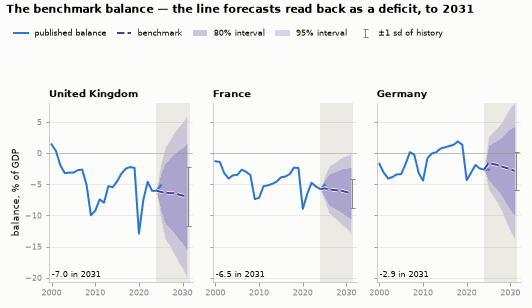

United Kingdom: ledger -6.04% of GDP in 2024 → benchmark -6.95% in 2031 [80% -15.44 to +1.54, 95% -19.94 to +6.03]
    interval from 23 statistical lines (rho_within +0.23, rho_between +0.05, 23 obs). Over 7 years this balance has moved with a standard deviation of 4.74 pp (29 windows), against the cone's 6.63.
    2025 is already published: benchmark -6.21 against an outturn of -5.18 — a miss of -1.02 pp, the only mark this construction carries so far.
France: ledger -5.76% of GDP in 2024 → benchmark -6.46% in 2031 [80% -10.61 to -2.31, 95% -12.81 to -0.11]
    interval from 19 statistical lines (rho_within +0.11, rho_between +0.01, 23 obs); 4 official line(s) add none. Over 7 years this balance has moved with a standard deviation of 2.28 pp (24 windows), against the cone's 3.24.
    2025 is already published: benchmark -5.67 against an outturn of -5.12 — a miss of -0.55 pp, the only mark this construction carries so far.
Germany: ledger -2.63% of GDP in 2024 → benchmark -2.86% in 203

In [94]:
balance_path()

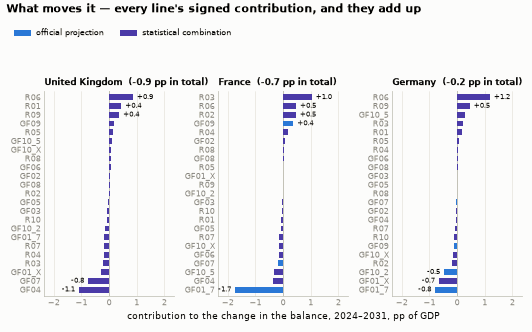

United Kingdom: the lines sum to -0.91 pp exactly. Widening it most — GF04 economic affairs -1.10; GF07
    health -0.76; GF01_X general public services excluding interest -0.28. Narrowing it most — R06 net
    social contributions +0.86; R01 value added tax +0.44; R09 sales of goods and services +0.36.
France: the lines sum to -0.70 pp exactly. Widening it most — GF01_7 public debt transactions (interest)
    -1.74; GF04 economic affairs -0.37; GF10_5 unemployment -0.34. Narrowing it most — R03 taxes on
    household income +1.04; R06 net social contributions +0.47; R02 other taxes on production and
    imports +0.46.
Germany: the lines sum to -0.23 pp exactly. Widening it most — GF01_7 public debt transactions
    (interest) -0.80; GF01_X general public services excluding interest -0.66; GF10_2 old age (pensions)
    -0.48. Narrowing it most — R06 net social contributions +1.19; R09 sales of goods and services
    +0.46; GF10_5 unemployment +0.28.


In [95]:
balance_contributions()

## 4.6 The benchmark against the WEO's own deficit projection

§4.1–4.3 put our totals beside the WEO's and stop at the last outturn, because
our ledger does. §4.5 carries a benchmark balance to 2031, and the WEO
publishes GGXCNL over exactly that horizon. So the two go on one axis at last —
and the more useful question is not which is lower but **where they part
company**.

**They start from the same place.** At the base year the balance gap is
**+0.02 pp of GDP** for the United Kingdom and zero to three decimals for
France and Germany. Nothing below is a definitional wedge in disguise.

**By side they do not.** The UK's `TR` and `TE` are each about **2.6 pp of GDP
larger** than the WEO's — a stable perimeter difference (sd 0.25 pp over ten
overlap years, classified `perimeter` in §8.2) that cancels in the balance
because it sits on both sides. So the side comparison below is of **changes
since the base year**, where a stable wedge cancels, and `perimeter_gap_pp` and
its standard deviation are published on every row rather than left to be
discovered.

The decomposition closes exactly:

> balance gap = revenue gap + expenditure gap − the WEO's own internal wedge

where the wedge is Δ((GGR − GGX − GGXCNL)/NGDP) — zero to four decimals on this
vintage, and carried anyway, because reporting it is cheaper than finding out
later that it was absorbed.

Two things worth holding on to while reading the charts:

* **The WEO is inside the benchmark's 80% interval in every year, for all three
  countries**, and never more than **0.97** of the benchmark's own standard
  errors away from it. A five-point gap sounds like a disagreement; on this
  cone it is not one. That is a statement about how wide six-year fiscal
  uncertainty is, not about how close the two forecasts are.
* **Where they differ, the difference is policy.** The benchmark knows only
  each line's own history; the WEO's projection embeds announced measures. That
  is the whole reason to put them side by side — and it is why this book reports
  how far apart they are and never which one is right.

Built by `ggfiscal benchmark-vs-weo` into
[`../deliverables/benchmark_vs_weo.csv`](../deliverables/benchmark_vs_weo.csv).


In [96]:
# --------------------------------------------- the benchmark against the WEO
#
# §4.1-4.3 compare our published totals with the WEO's and stop at the last
# outturn, because our ledger does. §4.5 carries a benchmark balance to 2031,
# and the WEO publishes GGXCNL over exactly that horizon, so the two finally
# go on one axis.
#
# Aqua is the IMF WEO here as everywhere else in this book, violet is the
# benchmark. The comparison is clean at the base year — the balance gap is
# +0.02 pp of GDP for the UK and zero to three decimals for France and
# Germany — so nothing below is a definitional wedge in disguise. By SIDE it
# is not: the UK's TR and TE are each about 2.6 pp of GDP larger than the
# WEO's, a stable perimeter difference that cancels in the balance. So the
# side comparison is made on changes since the base year, where a stable
# wedge cancels, and `perimeter_gap_pp` is published on every row.
#
# `ggfiscal benchmark-vs-weo` builds it; this notebook reads and plots.

VS_WEO = load("benchmark_vs_weo")
VS_BAL = VS_WEO.query("kind == 'balance'")


def weo_compare_path():
    """The two paths on one axis, with the benchmark's own cone around it."""
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 3.5 + 0.78), sharey=True)
    lo = min(VS_BAL.lo95.min(), VS_BAL.weo_pct_gdp.min(),
             min(_ledger_nlb(i).loc[BAL_FROM:].min() for i in COUNTRIES)) - 0.8
    hi = max(VS_BAL.hi95.max(), 0.8)
    height = 3.5 + 0.78

    for ax, iso3 in zip(axes, COUNTRIES):
        v = VS_WEO.query("iso3 == @iso3 and kind == 'balance'").sort_values("year")
        b = BAL.query("iso3 == @iso3").sort_values("year")
        base = int(v.base_year.iloc[0])
        anchor = float(b.anchor_pct_gdp.iloc[0])
        hist = _ledger_nlb(iso3).loc[BAL_FROM:]
        years = [base, *v.year]

        ax.set_xlim(BAL_FROM - 0.6, XMAX + 0.9)
        ax.set_ylim(lo, hi)
        ax.axvspan(base, XMAX + 0.9, color=SHADE, zorder=0, lw=0)
        ax.axhline(0, color=AXIS, lw=1, zorder=1)
        for low, high, alpha, lab in (("lo95", "hi95", 0.16, "95%"),
                                      ("lo80", "hi80", 0.32, "80%")):
            ax.fill_between(years, [anchor, *v[low]], [anchor, *v[high]],
                            color=VIOLET, alpha=alpha, lw=0, zorder=1,
                            label=f"benchmark {lab}")
        ax.plot(hist.index, hist.values, color=BLUE, label="published balance",
                zorder=3)
        ax.plot(years, [anchor, *v.ours_pct_gdp], color=VIOLET, ls="--",
                zorder=4, label="benchmark",
                path_effects=[withStroke(linewidth=3.6, foreground=SURFACE)])
        ax.plot(years, [anchor, *v.weo_pct_gdp], color=AQUA, ls="--", zorder=5,
                label="IMF WEO", path_effects=[withStroke(linewidth=3.6,
                                                          foreground=SURFACE)])
        # aqua sits below 3:1 on this surface, so the WEO carries a text
        # label on the mark as well as a legend entry
        end = v.iloc[-1]
        ax.annotate("WEO", (float(end.year), float(end.weo_pct_gdp)),
                    xytext=(4, 0), textcoords="offset points", color=AQUA,
                    fontsize=7.5, va="center")
        ax.set_title(NAME[iso3], fontsize=9.5)
        ax.grid(axis="y")
        ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
        ax.tick_params(labelsize=7.5)
        ax.annotate(f"{float(end.level_gap_pp):+.1f} pp apart in "
                    f"{int(end.year)}\n(the WEO is {abs(float(end.weo_z)):.2f} "
                    f"of the cone's\nstandard errors away)",
                    (0.02, 0.03), xycoords="axes fraction", fontsize=7,
                    color=INK, linespacing=1.35)

    axes[0].set_ylabel("balance, % of GDP")
    handles, labels = axes[0].get_legend_handles_labels()
    order = [labels.index(k) for k in ("published balance", "benchmark",
                                       "IMF WEO", "benchmark 80%",
                                       "benchmark 95%")]
    fig.legend([handles[i] for i in order], [labels[i] for i in order],
               loc="upper left", bbox_to_anchor=(0.012, 1 - 0.30 / height),
               ncol=5, fontsize=8, handlelength=1.8, columnspacing=1.2)
    fig.suptitle("The benchmark against the IMF WEO's own deficit projection",
                 fontsize=10.5, fontweight="bold", x=0.012, ha="left",
                 y=1 - 0.055 / height)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.78 / height))
    show(fig)

    for iso3 in COUNTRIES:
        v = VS_WEO.query("iso3 == @iso3 and kind == 'balance'").sort_values("year")
        end = v.iloc[-1]
        inside80 = int(v.weo_inside_80.sum())
        print(f"{NAME[iso3]}: {int(end.year)} — benchmark "
              f"{float(end.ours_pct_gdp):+.2f}% of GDP, WEO "
              f"{float(end.weo_pct_gdp):+.2f}%, {float(end.level_gap_pp):+.2f} pp "
              f"apart. The WEO is inside the benchmark's 80% interval in "
              f"{inside80} of {len(v)} years"
              + (f" and never more than {v.weo_z.abs().max():.2f} standard "
                 f"errors from it." if inside80 == len(v) else "."))
        print(f"    base {int(end.base_year)} perimeter gap "
              f"{float(end.perimeter_gap_pp):+.3f} pp on the balance "
              f"(sd {float(end.perimeter_gap_sd_pp):.3f} over the last ten "
              f"overlap years, classified {end.perimeter_classification}) — "
              f"which is why the comparison is of changes.")


def weo_compare_split():
    """Where the difference comes from: each side's change since the base
    year, ours against the WEO's. The vertical distance IS the gap, and the
    two distances sum to the distance between the balances."""
    sides = ("revenue", "expenditure")
    fig, axes = plt.subplots(2, 3, figsize=(7.4, 4.0 + 0.72), sharex=True)
    height = 4.0 + 0.72
    d = VS_WEO[VS_WEO.kind.isin(sides)]
    lo = min(d.ours_change_pp.min(), d.weo_change_pp.min()) - 0.5
    hi = max(d.ours_change_pp.max(), d.weo_change_pp.max()) + 0.5

    for col, iso3 in enumerate(COUNTRIES):
        for row, side in enumerate(sides):
            ax = axes[row][col]
            g = VS_WEO.query("iso3 == @iso3 and kind == @side").sort_values("year")
            base = int(g.base_year.iloc[0])
            years = [base, *g.year]
            ax.set_xlim(base - 0.3, XMAX + 0.4)
            ax.set_ylim(lo, hi)
            ax.axhline(0, color=AXIS, lw=1, zorder=0)
            ax.plot(years, [0.0, *g.ours_change_pp], color=VIOLET, ls="--",
                    zorder=3, label="benchmark")
            ax.plot(years, [0.0, *g.weo_change_pp], color=AQUA, ls="--",
                    zorder=3, label="IMF WEO")
            end = g.iloc[-1]
            ax.fill_between(years, [0.0, *g.ours_change_pp],
                            [0.0, *g.weo_change_pp], color=MUTED, alpha=0.16,
                            lw=0, zorder=1)
            ax.annotate(f"{float(end.change_gap_pp):+.1f}",
                        (float(end.year), (float(end.ours_change_pp)
                                           + float(end.weo_change_pp)) / 2),
                        xytext=(4, 0), textcoords="offset points",
                        fontsize=7.5, color=INK, va="center")
            ax.grid(axis="y")
            ax.tick_params(labelsize=7.5)
            ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(3))
            if row == 0:
                ax.set_title(NAME[iso3], fontsize=9.5)
            if col == 0:
                ax.set_ylabel(f"{side}\ncontribution, pp", fontsize=8)
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left",
               bbox_to_anchor=(0.012, 1 - 0.30 / height), ncol=2, fontsize=8,
               handlelength=1.8)
    fig.suptitle("Where the difference comes from — each side's change since "
                 "the base year", fontsize=10.5, fontweight="bold", x=0.012,
                 ha="left", y=1 - 0.055 / height)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.72 / height))
    show(fig)

    end_year = int(VS_WEO.year.max())
    print(f"Contributions to the gap at {end_year}, in pp of GDP. Positive "
          f"means our benchmark has the smaller deficit.")
    print(f"{'':16s} {'revenue':>18s} {'expenditure':>18s} {'wedge':>8s} "
          f"{'balance':>9s}")
    for iso3 in COUNTRIES:
        g = VS_WEO.query("iso3 == @iso3 and year == @end_year").set_index("kind")
        parts = [float(g.loc[k, "change_gap_pp"])
                 for k in ("revenue", "expenditure", "weo_internal_wedge")]
        total = float(g.loc["balance", "change_gap_pp"])
        assert abs(sum(parts) - total) < 1e-6, iso3
        print(f"{NAME[iso3]:16s} {parts[0]:+18.2f} {parts[1]:+18.2f} "
              f"{parts[2]:+8.2f} {total:+9.2f}")
    print(fill("Read a panel as: how far each side has moved since the base "
               "year, on our benchmark and on the WEO's projection. The "
               "shaded distance between the two lines is that side's "
               "contribution to the gap between the balances, and the three "
               "contributions add to it exactly. The benchmark knows only "
               "each line's own history and the WEO's projection embeds "
               "announced policy, so where they part company the difference "
               "IS the policy — this book reports how far apart they are, "
               "never which one is right.", 104))


print(f"benchmark vs WEO {VS_BAL.weo_vintage.iloc[0]}: {len(VS_BAL)} "
      f"country-years; the WEO falls inside the benchmark's 80% interval in "
      f"{int(VS_BAL.weo_inside_80.sum())} of them, and its largest distance "
      f"from the benchmark is {VS_BAL.weo_z.abs().max():.2f} standard errors.")


benchmark vs WEO 2026-04: 21 country-years; the WEO falls inside the benchmark's 80% interval in 21 of them, and its largest distance from the benchmark is 1.10 standard errors.


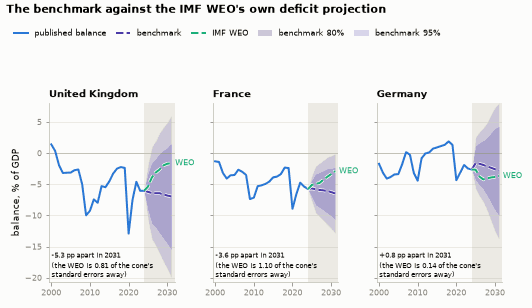

United Kingdom: 2031 — benchmark -6.95% of GDP, WEO -1.60%, -5.35 pp apart. The WEO is inside the benchmark's 80% interval in 7 of 7 years and never more than 0.85 standard errors from it.
    base 2024 perimeter gap +0.017 pp on the balance (sd 0.061 over the last ten overlap years, classified perimeter, unexplained) — which is why the comparison is of changes.
France: 2031 — benchmark -6.46% of GDP, WEO -2.89%, -3.57 pp apart. The WEO is inside the benchmark's 80% interval in 7 of 7 years and never more than 1.10 standard errors from it.
    base 2024 perimeter gap -0.001 pp on the balance (sd 0.023 over the last ten overlap years, classified revision) — which is why the comparison is of changes.
Germany: 2031 — benchmark -2.86% of GDP, WEO -3.66%, +0.80 pp apart. The WEO is inside the benchmark's 80% interval in 7 of 7 years and never more than 0.78 standard errors from it.
    base 2024 perimeter gap +0.000 pp on the balance (sd 0.000 over the last ten overlap years, classified rev

In [97]:
weo_compare_path()

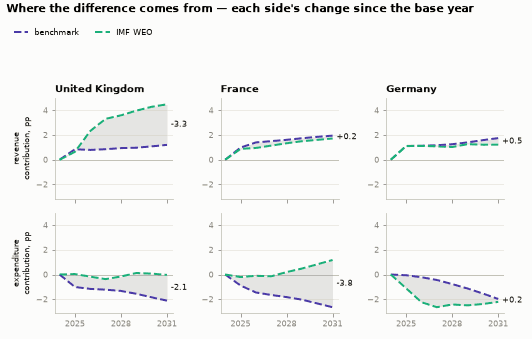

Contributions to the gap at 2031, in pp of GDP. Positive means our benchmark has the smaller deficit.
                            revenue        expenditure    wedge   balance
United Kingdom                -3.28              -2.08    -0.00     -5.36
France                        +0.23              -3.82    -0.00     -3.59
Germany                       +0.53              +0.24    +0.00     +0.77
Read a panel as: how far each side has moved since the base year, on our benchmark and on the WEO's
projection. The shaded distance between the two lines is that side's contribution to the gap between the
balances, and the three contributions add to it exactly. The benchmark knows only each line's own
history and the WEO's projection embeds announced policy, so where they part company the difference IS
the policy — this book reports how far apart they are, never which one is right.


In [98]:
weo_compare_split()

---

# 5. The two TE numbers

Point 5 of the schema notes, charted. The COFOG tree's `TE` comes from the
expenditure anchor; the ledger's `TE` comes from the balance anchor. For France
and Germany these are the same Eurostat table and agree to rounding. For the UK
they are two different ONS tables — ESA Table 11 against the general-government
receipts-and-expenditure table — so they can and do differ.

Neither is wrong. They are different published totals, and the pipeline keeps
both rather than picking one, so which anchor a number came from stays visible.

Both series are outturn-only, so as in §4 the projection region is shaded and
empty. Same country axis as everything else.

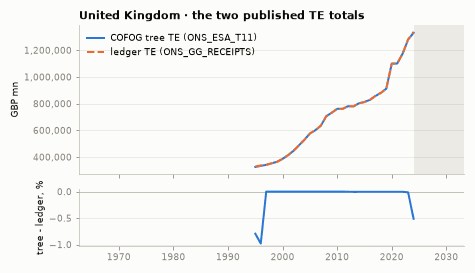

worst absolute difference 0.9808% in 1996


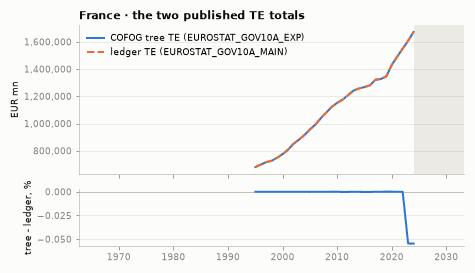

worst absolute difference 0.0547% in 2024


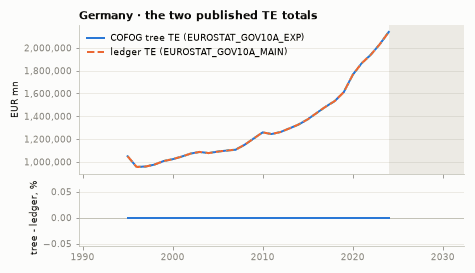

worst absolute difference 0.0000% in 1995


In [99]:
def te_compare(iso3):
    tree = (TREE.query("iso3 == @iso3 and line_code == 'TE' and "
                       "variant == 'strict'").sort_values("year"))
    led = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    both = tree[["year", "value_lcu_mn", "source_id"]].merge(
        led[["year", "te_lcu_mn", "source_id"]], on="year",
        suffixes=("_tree", "_ledger"))
    both["diff_pct"] = 100 * (both.value_lcu_mn - both.te_lcu_mn) / both.te_lcu_mn

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(6.6, 3.8), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(both.year, both.value_lcu_mn, color=BLUE,
            label=f"COFOG tree TE ({both.source_id_tree.iloc[0]})")
    ax.plot(both.year, both.te_lcu_mn, color=ORANGE, ls="--",
            label=f"ledger TE ({both.source_id_ledger.iloc[0]})")
    ax.set_xlim(*XLIM[iso3])
    ax.axvspan(both.year.max(), XLIM[iso3][1], color=SHADE, zorder=0, lw=0)
    ax.set_title(f"{NAME[iso3]} · the two published TE totals")
    ax.set_ylabel(f"{tree.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(both.year, both.diff_pct, color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("tree - ledger, %")
    gx.grid(axis="y")
    gx.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    fig.tight_layout()
    show(fig)
    print(f"worst absolute difference {both.diff_pct.abs().max():.4f}% "
          f"in {int(both.loc[both.diff_pct.abs().idxmax(), 'year'])}")


for iso3 in ("GBR", "FRA", "DEU"):
    te_compare(iso3)

---

# 6. Where the seams are

A last pass over the whole book: every seam in every series, counted and listed,
so nothing charted above goes unnoticed. Each row is a year where a series
changes source or construction method — the dotted rules in the charts.

In [100]:
rows = []
for (iso3, line), g in TREE.query("variant == 'maximum_extension'").groupby(
        ["iso3", "line_code"]):
    for year in _seams(g):
        prev = g.query("year == @year - 1").iloc[0]
        curr = g.query("year == @year").iloc[0]
        rows.append({"iso3": iso3, "line": line, "seam_year": year,
                     "from": f"{prev.observation_type} ({prev.source_id})",
                     "to": f"{curr.observation_type} ({curr.source_id})",
                     "step_pct": round(100 * (curr.value_lcu_mn
                                              / prev.value_lcu_mn - 1), 2)})
seams = pd.DataFrame(rows).sort_values(["iso3", "line", "seam_year"])
print(f"{len(seams)} seams across {seams.groupby(['iso3', 'line']).ngroups} series")
seams.reset_index(drop=True)

138 seams across 74 series


,iso3,line,seam_year,from,to,step_pct
0,DEU,E01,1995,stitched_actual (EC_AMECO),anchor_actual (EUROSTAT_GOV10A_MAIN),6.25
1,DEU,E01,2026,anchor_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),4.45
2,DEU,E02,1995,stitched_actual (EC_AMECO),anchor_actual (EUROSTAT_GOV10A_MAIN),5.17
3,DEU,E02,2026,anchor_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),5.54
4,DEU,E03,1995,stitched_actual (EC_AMECO),anchor_actual (EUROSTAT_GOV10A_MAIN),6.05
...,...,...,...,...,...,...
133,GBR,R06,2028,direct_forecast (EC_AMECO),direct_forecast (OBR_EFO_LATEST),3.48
134,GBR,R06_E,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),10.14
135,GBR,R06_E,2026,anchor_actual (ONS_GG_RECEIPTS),direct_forecast (OBR_EFO_LATEST),8.50
136,GBR,R06_H,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),-4.71


`step_pct` is the year-on-year change *across* the seam. It is not an error
term — spending and revenue really do change from year to year — but an
outsized value at a seam is the first place to look if a series seems wrong. Sort
by it to triage:

In [101]:
seams.reindex(seams.step_pct.abs().sort_values(ascending=False).index).head(15)

,iso3,line,seam_year,from,to,step_pct
17,DEU,E09,1995,stitched_actual (EC_AMECO),anchor_actual (EUROSTAT_GOV10A_MAIN),528.66
107,GBR,E09,1990,stitched_actual (EC_AMECO),anchor_actual (ONS_GG_RECEIPTS),191.07
29,DEU,GF04,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),141.04
34,DEU,GF08,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),38.67
126,GBR,R03,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),22.57
105,GBR,E08,1990,stitched_actual (EC_AMECO),derived_actual (ONS_GG_RECEIPTS),21.99
67,FRA,E05,2026,anchor_actual (EUROSTAT_GOV10A_MAIN),direct_forecast (EC_AMECO),19.04
76,FRA,GF01,2026,stitched_actual (EC_AMECO),proxy_forecast (EC_AMECO),19.04
79,FRA,GF01_7,2026,stitched_actual (EC_AMECO),direct_forecast (EC_AMECO),19.04
113,GBR,GF01_7,2025,anchor_actual (ONS_ESA_T11),stitched_actual (EC_AMECO),18.81
